In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd


In [20]:
# not set up yet
import wandb

super_secret_API_key = "d1678741bcd8eb1d90ca26aa8f2bf079256ac391"

wandb.login(key=super_secret_API_key)

WANDB_PROJECT = "ZNEUS_project2_cnn"
WANDB_ENTITY = None  # getpass.getuser()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\bizon\_netrc


In [22]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.randn(1).cuda())

print("CUDA available:", torch.cuda.is_available())


print("Current device index:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0))


2.9.1+cu130
13.0
tensor([-0.4082], device='cuda:0')
CUDA available: True
Current device index: 0
Device name: NVIDIA GeForce RTX 3060 Laptop GPU


In [23]:
from dataclasses import dataclass, asdict


@dataclass
class Config:
    CSV_FILE: str = "images/sports.csv"
    ROOT_DIR: str = "images"
    BATCH_SIZE: int = 64
    NUM_EPOCHS: int = 200
    LEARNING_RATE: float = 0.001
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = -1
    PIN_MEMORY: bool = True
    DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    PATIENCE: int = 50
    LR_SCHEDULER: str = "cosine"


config = Config()

In [26]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels):
        super(CustomCNN, self).__init__()
        # 1
        self.conv1 = nn.Conv2d(
            in_channels=in_channels, out_channels=32, kernel_size=(3, 3), padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 2
        self.conv2 = nn.Conv2d(
            in_channels=32, out_channels=64, kernel_size=(3, 3), padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # 3
        self.conv3 = nn.Conv2d(
            in_channels=64, out_channels=128, kernel_size=(3, 3), padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.flatten = nn.Flatten()
        # self.dropout1 = nn.Dropout(0.25)

        self.lin1 = nn.Linear(128 * 4 * 4, 256)
        self.bn4 = nn.BatchNorm1d(256)
        # self.dropout2 = nn.Dropout(0.5)
        self.lin2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)

        x = self.adaptive_pool(x)

        x = self.flatten(x)
        # x = self.dropout1(x)

        x = self.lin1(x)
        x = self.bn4(x)
        x = F.relu(x)
        # x = self.dropout2(x)

        x = self.lin2(x)
        return x


class ImprovedCustomCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3, dropout_p=0.2):
        super(ImprovedCustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        # pooling
        self.pool = nn.MaxPool2d(2, 2)

        # global pooling to compress spatial dims
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        # classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        # Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)

        # Global pool -> flatten -> classifier
        x = self.global_pool(x)  # -> (B, 128, 1, 1)
        x = self.flatten(x)  # -> (B, 128)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [27]:
SPORT_CATEGORIES = {
    "vehicles": [
        "bike polo",
        "formula 1 racing",
        "hydroplane racing",
        "motorcycle racing",
        "nascar racing",
        "rollerblade racing",
        "sidecar racing",
        "snowmobile racing",
        "track bicycle",
        "wheelchair racing",
    ],
    "summer": [
        "archery",
        "axe throwing",
        "barell racing",
        "baseball",
        "basketball",
        "cricket",
        "croquet",
        "disc golf",
        "field hockey",
        "frisbee",
        "golf",
        "hammer throw",
        "high jump",
        "hurdles",
        "javelin",
        "lacrosse",
        "pole vault",
        "shot put",
        "tennis",
        "tug of war",
        "ultimate",
    ],
    "winter": [
        "bobsled",
        "curling",
        "figure skating men",
        "figure skating pairs",
        "figure skating women",
        "giant slalom",
        "hockey",
        "ice climbing",
        "ice yachting",
        "luge",
        "mushing",
        "ski jumping",
        "snow boarding",
        "speed skating",
    ],
    "water": [
        "canoe slamon",
        "fly fishing",
        "hydroplane racing",
        "rowing",
        "sailboat racing",
        "surfing",
        "swimming",
        "water cycling",
        "water polo",
    ],
    "indoor": [
        "air hockey",
        "shuffleboard",
        "balance beam",
        "billiards",
        "bowling",
        "cheerleading",
        "jai alai",
        "parallel bar",
        "pole dancing",
        "pommel horse",
        "rings",
        "table tennis",
        "uneven bars",
        "volleyball",
        "weightlifting",
        "wheelchair basketball",
    ],
    "outdoor": [
        "ampute football",
        "baton twirling",
        "bmx",
        "bull riding",
        "bungee jumping",
        "chuckwagon racing",
        "disc golf",
        "football",
        "gaga",
        "hang gliding",
        "harness racing",
        "horse jumping",
        "horse racing",
        "horseshoe pitching",
        "jousting",
        "log rolling",
        "pole climbing",
        "polo",
        "rock climbing",
        "roller derby",
        "rugby",
        "sky surfing",
        "skydiving",
        "steer wrestling",
        "trapeze",
        "wingsuit flying",
    ],
    "combat": [
        "arm wrestling",
        "boxing",
        "fencing",
        "judo",
        "olympic wrestling",
        "sumo wrestling",
    ],
}
LABEL_TO_CATEGORY = {}

for category, sports in SPORT_CATEGORIES.items():
    for sport in sports:
        LABEL_TO_CATEGORY[sport] = category

len(LABEL_TO_CATEGORY)
LABEL_TO_CATEGORY

{'bike polo': 'vehicles',
 'formula 1 racing': 'vehicles',
 'hydroplane racing': 'water',
 'motorcycle racing': 'vehicles',
 'nascar racing': 'vehicles',
 'rollerblade racing': 'vehicles',
 'sidecar racing': 'vehicles',
 'snowmobile racing': 'vehicles',
 'track bicycle': 'vehicles',
 'wheelchair racing': 'vehicles',
 'archery': 'summer',
 'axe throwing': 'summer',
 'barell racing': 'summer',
 'baseball': 'summer',
 'basketball': 'summer',
 'cricket': 'summer',
 'croquet': 'summer',
 'disc golf': 'outdoor',
 'field hockey': 'summer',
 'frisbee': 'summer',
 'golf': 'summer',
 'hammer throw': 'summer',
 'high jump': 'summer',
 'hurdles': 'summer',
 'javelin': 'summer',
 'lacrosse': 'summer',
 'pole vault': 'summer',
 'shot put': 'summer',
 'tennis': 'summer',
 'tug of war': 'summer',
 'ultimate': 'summer',
 'bobsled': 'winter',
 'curling': 'winter',
 'figure skating men': 'winter',
 'figure skating pairs': 'winter',
 'figure skating women': 'winter',
 'giant slalom': 'winter',
 'hockey': 

In [30]:
class SportsDataset(Dataset):
    def __init__(self, csv_file, root_dir, dataset_type, transform=None):
        df = pd.read_csv(csv_file).copy()
        df["category"] = df["labels"].map(LABEL_TO_CATEGORY)

        self.df = df[df["data set"] == dataset_type].reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

        # SPORT classes
        self.sport_classes = sorted(self.df["labels"].unique())
        self.sport_to_idx = {cls: idx for idx, cls in enumerate(self.sport_classes)}

        # CATEGORY classes
        self.category_classes = sorted(self.df["category"].unique())
        self.category_to_idx = {
            cls: idx for idx, cls in enumerate(self.category_classes)
        }

        # ADD THIS: Build sport_classes_per_category
        self.sport_classes_per_category = {}
        for category in self.category_classes:
            # Get all unique sports that belong to this category in the dataset
            sports_in_cat = self.df[self.df["category"] == category]["labels"].unique()
            self.sport_classes_per_category[category] = sorted(sports_in_cat)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["filepaths"])
        image = Image.open(img_path).convert("RGB")

        sport_label = self.sport_to_idx[row["labels"]]
        category_label = self.category_to_idx[row["category"]]

        if self.transform:
            image = self.transform(image)

        return image, category_label, sport_label


In [31]:
train_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.ToTensor(),  # <-- move this up
        # transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        # transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),  # now sees a tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


test_transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# trainset = SportsDataset("images/sports.csv", "images", "train", train_transform)
# validset = SportsDataset("images/sports.csv", "images", "valid", test_transform)
# testset = SportsDataset("images/sports.csv", "images", "test", test_transform)

# trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
# validloader = DataLoader(validset, batch_size=32, shuffle=False)
# testloader = DataLoader(testset, batch_size=32, shuffle=False)

# print(f"Train dataset size: {len(trainset)}")
# print(f"Valid dataset size: {len(validset)}")
# print(f"Test dataset size: {len(testset)}")

trainset = SportsDataset("images/sports.csv", "images", "train", train_transform)
print(trainset.df.category.unique())
trainset.sport_classes_per_category

['indoor' 'outdoor' 'summer' 'combat' 'vehicles' 'winter' 'water']


{'combat': ['arm wrestling',
  'boxing',
  'fencing',
  'judo',
  'olympic wrestling',
  'sumo wrestling'],
 'indoor': ['air hockey',
  'balance beam',
  'billiards',
  'bowling',
  'cheerleading',
  'jai alai',
  'parallel bar',
  'pole dancing',
  'pommel horse',
  'rings',
  'shuffleboard',
  'table tennis',
  'uneven bars',
  'volleyball',
  'weightlifting',
  'wheelchair basketball'],
 'outdoor': ['ampute football',
  'baton twirling',
  'bmx',
  'bull riding',
  'bungee jumping',
  'chuckwagon racing',
  'disc golf',
  'football',
  'gaga',
  'hang gliding',
  'harness racing',
  'horse jumping',
  'horse racing',
  'horseshoe pitching',
  'jousting',
  'log rolling',
  'pole climbing',
  'polo',
  'rock climbing',
  'roller derby',
  'rugby',
  'sky surfing',
  'skydiving',
  'steer wrestling',
  'trapeze',
  'wingsuit flying'],
 'summer': ['archery',
  'axe throwing',
  'barell racing',
  'baseball',
  'basketball',
  'cricket',
  'croquet',
  'field hockey',
  'frisbee',
  'go

In [4]:
# RGB intenzita
# import matplotlib.pyplot as plt
# import numpy as np
# from tqdm import tqdm


# def analyze_rgb_intensity(dataset, classes):
#     """
#     Analyze RGB intensity distribution across the dataset
#     """
#     rgb_means = {"R": [], "G": [], "B": []}

#     print("Analyzing RGB intensities...")
#     for idx in tqdm(range(len(dataset))):
#         image, _ = dataset[idx]

#         # If image is normalized, denormalize it first
#         if image.min() < 0:  # Check if normalized
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         rgb_means["R"].append(image[0].mean().item())
#         rgb_means["G"].append(image[1].mean().item())
#         rgb_means["B"].append(image[2].mean().item())

#     # Plot RGB distribution
#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     colors = ["red", "green", "blue"]
#     channels = ["R", "G", "B"]

#     for ax, color, channel in zip(axes, colors, channels):
#         ax.hist(rgb_means[channel], bins=50, color=color, alpha=0.7, edgecolor="black")
#         ax.set_xlabel(f"{channel} Intensity")
#         ax.set_ylabel("Frequency")
#         ax.set_title(f"{channel} Channel Distribution")
#         ax.axvline(
#             np.mean(rgb_means[channel]),
#             color="black",
#             linestyle="--",
#             label=f"Mean: {np.mean(rgb_means[channel]):.3f}",
#         )
#         ax.legend()

#     plt.tight_layout()
#     plt.savefig("rgb_intensity_distribution.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     return rgb_means


# def compute_average_images_per_class(dataset, classes):
#     """
#     Compute and visualize average image for each class
#     """
#     # Initialize accumulators for each class
#     class_sums = {cls: torch.zeros(3, 64, 64) for cls in classes}
#     class_counts = {cls: 0 for cls in classes}

#     print("Computing average images per class...")
#     for idx in tqdm(range(len(dataset))):
#         image, label = dataset[idx]
#         class_name = classes[label]

#         # Denormalize if needed
#         if image.min() < 0:
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         class_sums[class_name] += image
#         class_counts[class_name] += 1

#     # Compute averages
#     average_images = {}
#     for cls in classes:
#         average_images[cls] = class_sums[cls] / class_counts[cls]

#     # Visualize average images
#     num_classes = len(classes)
#     cols = 5
#     rows = (num_classes + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
#     axes = axes.flatten() if num_classes > 1 else [axes]

#     for idx, cls in enumerate(classes):
#         avg_img = average_images[cls].permute(1, 2, 0).numpy()
#         avg_img = np.clip(avg_img, 0, 1)  # Ensure values are in [0, 1]

#         axes[idx].imshow(avg_img)
#         axes[idx].set_title(f"{cls}\n(n={class_counts[cls]})", fontsize=10)
#         axes[idx].axis("off")

#     # Hide extra subplots
#     for idx in range(num_classes, len(axes)):
#         axes[idx].axis("off")

#     plt.tight_layout()
#     plt.savefig("average_images_per_class.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     return average_images, class_counts


# def plot_rgb_by_class(dataset, classes):
#     """
#     Plot RGB intensity distribution for each class
#     """
#     class_rgb = {cls: {"R": [], "G": [], "B": []} for cls in classes}

#     print("Analyzing RGB by class...")
#     for idx in tqdm(range(len(dataset))):
#         image, label = dataset[idx]
#         class_name = classes[label]

#         # Denormalize if needed
#         if image.min() < 0:
#             mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
#             std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
#             image = image * std + mean

#         class_rgb[class_name]["R"].append(image[0].mean().item())
#         class_rgb[class_name]["G"].append(image[1].mean().item())
#         class_rgb[class_name]["B"].append(image[2].mean().item())

#     # Plot
#     num_classes = len(classes)
#     cols = 3
#     rows = (num_classes + cols - 1) // cols

#     fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
#     axes = axes.flatten() if num_classes > 1 else [axes]

#     for idx, cls in enumerate(classes):
#         ax = axes[idx]

#         # Create histogram for each channel
#         ax.hist(class_rgb[cls]["R"], bins=30, alpha=0.5, label="Red", color="red")
#         ax.hist(class_rgb[cls]["G"], bins=30, alpha=0.5, label="Green", color="green")
#         ax.hist(class_rgb[cls]["B"], bins=30, alpha=0.5, label="Blue", color="blue")

#         ax.set_xlabel("Intensity")
#         ax.set_ylabel("Frequency")
#         ax.set_title(f"{cls}")
#         ax.legend()

#     # Hide extra subplots
#     for idx in range(num_classes, len(axes)):
#         axes[idx].axis("off")

#     plt.tight_layout()
#     plt.savefig("rgb_by_class.png", dpi=300, bbox_inches="tight")
#     plt.show()

#     # Print statistics
#     print("\nRGB Statistics by Class:")
#     print("-" * 70)
#     for cls in classes:
#         r_mean = np.mean(class_rgb[cls]["R"])
#         g_mean = np.mean(class_rgb[cls]["G"])
#         b_mean = np.mean(class_rgb[cls]["B"])
#         print(f"{cls:20} | R: {r_mean:.3f} | G: {g_mean:.3f} | B: {b_mean:.3f}")


# # 1. RGB Intensity Distribution (overall)
# rgb_stats = analyze_rgb_intensity(trainset, trainset.classes)

# # 2. Average images per class
# avg_images, counts = compute_average_images_per_class(trainset, trainset.classes)

# # 3. RGB distribution by class
# plot_rgb_by_class(trainset, trainset.classes)

In [32]:
class CategoryOnlyDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, category, sport = self.base[idx]
        return image, category


In [33]:
train_base = SportsDataset(
    config.CSV_FILE, "images", "train", transform=train_transform
)
valid_base = SportsDataset(config.CSV_FILE, "images", "valid", transform=test_transform)
test_base = SportsDataset(config.CSV_FILE, "images", "test", transform=test_transform)

trainset_cat = CategoryOnlyDataset(train_base)
validset_cat = CategoryOnlyDataset(valid_base)
testset_cat = CategoryOnlyDataset(test_base)

trainloader_cat = DataLoader(trainset_cat, batch_size=64, shuffle=True)
validloader_cat = DataLoader(validset_cat, batch_size=64)
testloader_cat = DataLoader(testset_cat, batch_size=64)

model = CustomCNN(num_classes=len(train_base.category_classes), in_channels=3)
model = model.to(config.DEVICE)


model_improved = ImprovedCustomCNN(
    num_classes=len(train_base.category_classes), in_channels=3
)
model_improved = model_improved.to(config.DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [34]:
def train(
    name,
    model,
    testloader,
    trainloader,
    validloader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=config.NUM_EPOCHS,
    patience=config.PATIENCE,
):
    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=name,
        config={
            "epochs": epochs,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "architecture": model.__class__.__name__,
        },
    )

    wandb.watch(model, criterion, log="all", log_freq=100)

    best_loss = float("inf")  # <-- important
    best_epoch = 0
    models_dir = "./models"
    os.makedirs(models_dir, exist_ok=True)

    print(50 * "-", f"training model {name}", 50 * "-")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(trainloader.dataset)

        # ---- validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(validloader.dataset)

        scheduler.step()
        test_accuracy = test(model, testloader, device)

        # Save best model by lowest validation loss
        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), f"./models/{name}")
            print("  → Saved best model")

        # Early stopping AFTER updating best_epoch
        if epoch - best_epoch >= patience:
            print("Early stopping at epoch", epoch)
            break

        wandb.log(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "test_accuracy": test_accuracy,
                "patience": (epoch - best_epoch),
            }
        )

        print(
            f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
        )

    print("Training finished!")
    wandb.finish()
    print("run stats saved to wandb")
    return test_accuracy


def test(model, testloader, device):
    model.eval()
    correct = 0
    total = 0
    print("testing initiated")
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy


In [77]:
train(
    name="category_classifier_v2",
    model=model,
    testloader=testloader_cat,
    trainloader=trainloader_cat,
    validloader=validloader_cat,
    criterion=criterion,
    optimizer=optimizer,
    device=config.DEVICE,
    epochs=config.NUM_EPOCHS,
    scheduler=scheduler,
)

epoch,▁▃▆█
learning_rate,█▇▄▁
patience,▁▃▆█
test_accuracy,▁▇▅█
train_loss,█▄▃▁
val_loss,█▄▄▁
epoch,3
learning_rate,0.0009
patience,3
test_accuracy,0.608
train_loss,1.16439


-------------------------------------------------- training model category_classifier_v2 --------------------------------------------------
testing initiated
Test Accuracy: 0.6000
  → Saved best model
Epoch 0 | Train Loss: 1.0981 | Val Loss: 0.9912
testing initiated
Test Accuracy: 0.6640
  → Saved best model
Epoch 1 | Train Loss: 1.0620 | Val Loss: 0.9183
testing initiated
Test Accuracy: 0.6380
Epoch 2 | Train Loss: 1.0315 | Val Loss: 0.9464
testing initiated
Test Accuracy: 0.6220
  → Saved best model
Epoch 3 | Train Loss: 1.0013 | Val Loss: 0.8842
testing initiated
Test Accuracy: 0.6800
  → Saved best model
Epoch 4 | Train Loss: 0.9728 | Val Loss: 0.7930
testing initiated
Test Accuracy: 0.6740
Epoch 5 | Train Loss: 0.9368 | Val Loss: 0.8187
testing initiated
Test Accuracy: 0.7000
Epoch 6 | Train Loss: 0.9074 | Val Loss: 0.8168
testing initiated
Test Accuracy: 0.7380
  → Saved best model
Epoch 7 | Train Loss: 0.8795 | Val Loss: 0.7526
testing initiated
Test Accuracy: 0.7120
Epoch 8 | T

KeyboardInterrupt: 

In [35]:
class SportDatasetForCategory(Dataset):
    """Returns only sports from a specific category"""

    def __init__(self, base_dataset, category_name):
        self.base = base_dataset
        self.indices = []
        self.sports_in_category = []

        # Find all images in this category
        for idx in range(len(base_dataset)):
            image, cat_label, sport_label = base_dataset[idx]
            cat = base_dataset.category_classes[cat_label]

            if cat == category_name:
                self.indices.append(idx)
                sport = base_dataset.sport_classes[sport_label]
                if sport not in self.sports_in_category:
                    self.sports_in_category.append(sport)

        self.sports_in_category.sort()
        self.sport_to_idx = {s: i for i, s in enumerate(self.sports_in_category)}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, _, sport_label = self.base[real_idx]

        # Convert to local sport index
        sport_name = self.base.sport_classes[sport_label]
        local_sport_idx = self.sport_to_idx[sport_name]

        return image, local_sport_idx


def train_models_per_category(train_base, valid_base, test_base, config, device):
    """
    Simple function that trains one CNN per category
    Returns dictionary of trained models
    """
    import os

    os.makedirs("./models", exist_ok=True)

    trained_models = {}
    results = {}

    for category in train_base.category_classes:
        print(f"\n{'=' * 60}")
        print(f"Training model for: {category}")
        print(f"{'=' * 60}")

        # Create datasets for this category
        train_cat = SportDatasetForCategory(train_base, category)
        valid_cat = SportDatasetForCategory(valid_base, category)
        test_cat = SportDatasetForCategory(test_base, category)

        if len(train_cat) < 10:
            print(f"Skipping {category}: not enough data")
            continue

        print(f"Sports in {category}: {len(train_cat.sports_in_category)}")
        print(f"Training samples: {len(train_cat)}")

        # Create dataloaders
        train_loader = DataLoader(train_cat, batch_size=32, shuffle=True)
        valid_loader = DataLoader(valid_cat, batch_size=32, shuffle=False)
        test_loader = DataLoader(test_cat, batch_size=32, shuffle=False)
        print("created data loaders")
        # Create model
        num_sports = len(train_cat.sports_in_category)
        model = CustomCNN(num_classes=num_sports, in_channels=3).to(device)

        # Train
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
        print("criterion, optimizer and scheduler initialized\nBeggining to train")

        test_acc = train(
            name=f"sport_classifier_v2_{category}",
            model=model,
            testloader=test_loader,
            trainloader=train_loader,
            validloader=valid_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            epochs=50,
            patience=10,
        )

        # Save results
        trained_models[category] = model
        results[category] = {
            "num_sports": num_sports,
            "sports": train_cat.sports_in_category,
            "test_accuracy": test_acc,
        }

    # Print summary
    print(f"\n{'=' * 60}")
    print("TRAINING COMPLETE - SUMMARY")
    print(f"{'=' * 60}")
    for cat, info in results.items():
        print(
            f"{cat:15s}: {info['num_sports']:2d} sports, Acc: {info['test_accuracy']:.4f}"
        )

    return trained_models, results

In [36]:
sport_models, results = train_models_per_category(
    train_base=train_base,
    valid_base=valid_base,
    test_base=test_base,
    config=config,
    device=config.DEVICE,
)


Training model for: combat
Sports in combat: 6
Training samples: 800
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_v2_combat --------------------------------------------------
testing initiated
Test Accuracy: 0.4000
  → Saved best model
Epoch 0 | Train Loss: 1.2941 | Val Loss: 1.1334
testing initiated
Test Accuracy: 0.6333
  → Saved best model
Epoch 1 | Train Loss: 0.9396 | Val Loss: 0.8763
testing initiated
Test Accuracy: 0.6667
  → Saved best model
Epoch 2 | Train Loss: 0.8540 | Val Loss: 0.6831
testing initiated
Test Accuracy: 0.7333
  → Saved best model
Epoch 3 | Train Loss: 0.8151 | Val Loss: 0.4811
testing initiated
Test Accuracy: 0.7667
Epoch 4 | Train Loss: 0.7209 | Val Loss: 0.5434
testing initiated
Test Accuracy: 0.7000
Epoch 5 | Train Loss: 0.6717 | Val Loss: 0.5184
testing initiated
Test Accuracy: 0.6000
Epoch 6 | Train Loss: 0.6385 | Val Loss: 0.5589
testing initiated
Test Accuracy: 0.8000
  → Saved best model
Epoch 7 | Train Loss: 0.5942 | Val Loss: 0.4786
testing initiated
Test Accuracy: 0.8333
  → Sav

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,███▇▇▆▆▅▅▄▃▂▂▂▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇██████▇▇▇▆
patience,▁▁▁▁▂▃▁▁▁▂▃▁▂▃▃▅▆▁▁▂▁▂▃▃▄▆▁▂▃▁▃▃▁▂▃▄▅▆▆█
test_accuracy,▁▄▅▆▆▄▇▇▇▆▇▇▇▆▇▇▇▇▇▇█▇▇▇▆▇▇▇▇▆▅▆▇▆▇▅▆▆▆▇
train_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▁
val_loss,█▆▅▃▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▃▁▃▂▃▂▃▁▂
epoch,47
learning_rate,0.00065
patience,9
test_accuracy,0.83333
train_loss,0.24682


run stats saved to wandb

Training model for: indoor
Sports in indoor: 16
Training samples: 2116
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_v2_indoor --------------------------------------------------
testing initiated
Test Accuracy: 0.4500
  → Saved best model
Epoch 0 | Train Loss: 2.2825 | Val Loss: 2.0486
testing initiated
Test Accuracy: 0.4875
  → Saved best model
Epoch 1 | Train Loss: 1.9631 | Val Loss: 1.8279
testing initiated
Test Accuracy: 0.6375
  → Saved best model
Epoch 2 | Train Loss: 1.7798 | Val Loss: 1.5748
testing initiated
Test Accuracy: 0.6500
  → Saved best model
Epoch 3 | Train Loss: 1.6866 | Val Loss: 1.4475
testing initiated
Test Accuracy: 0.6750
  → Saved best model
Epoch 4 | Train Loss: 1.5820 | Val Loss: 1.3773
testing initiated
Test Accuracy: 0.6125
  → Saved best model
Epoch 5 | Train Loss: 1.4888 | Val Loss: 1.3473
testing initiated
Test Accuracy: 0.6625
  → Saved best model
Epoch 6 | Train Loss: 1.4442 | Val Loss: 1.2995
testing initiated
Test Accuracy: 0.6500
  → Saved best model
Epoch 7 | Train Loss: 1.3647 | V

...

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,███▇▆▅▄▄▃▃▂▂▁▁▁▁▁▁▂▂▃▃▄▄▅▆▇▇▇██████▇▇▆▆▄
patience,▁▁▁▂▁▁▂▃▄▁▃▁▂▁▁▂▃▄▅▆▁▂▃▄▅█▁▂▃▄▂▁▂▃▄▁▂▃▄▆
test_accuracy,▁▃▄▅▆▅▅▇▇▆▇▇▆▇▇▇▇▇▇█▇█▇▆▇▇▆▅▅▆▆▇▆▇▇▇▇▇▆█
train_loss,█▅▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val_loss,█▇▅▆▅▄▄▄▄▃▅▃▃▃▂▂▂▂▂▂▂▃▂▃▃▂▂▂▂▂▁▂▃▂▂▁▃▂▂▁
epoch,49
learning_rate,0.0005
patience,5
test_accuracy,0.91111
train_loss,0.26775


run stats saved to wandb

Training model for: winter
Sports in winter: 14
Training samples: 1900
created data loaders
criterion, optimizer and scheduler initialized
Beggining to train


-------------------------------------------------- training model sport_classifier_v2_winter --------------------------------------------------
testing initiated
Test Accuracy: 0.5143
  → Saved best model
Epoch 0 | Train Loss: 2.2041 | Val Loss: 1.9305
testing initiated
Test Accuracy: 0.5571
  → Saved best model
Epoch 1 | Train Loss: 1.8272 | Val Loss: 1.6414
testing initiated
Test Accuracy: 0.5857
  → Saved best model
Epoch 2 | Train Loss: 1.6305 | Val Loss: 1.5112
testing initiated
Test Accuracy: 0.6857
  → Saved best model
Epoch 3 | Train Loss: 1.4863 | Val Loss: 1.2180
testing initiated
Test Accuracy: 0.6571
Epoch 4 | Train Loss: 1.3449 | Val Loss: 1.4595
testing initiated
Test Accuracy: 0.6571
  → Saved best model
Epoch 5 | Train Loss: 1.3030 | Val Loss: 1.1709
testing initiated
Test Accuracy: 0.7571
  → Saved best model
Epoch 6 | Train Loss: 1.2464 | Val Loss: 0.9766
testing initiated
Test Accuracy: 0.7714
  → Saved best model
Epoch 7 | Train Loss: 1.1179 | Val Loss: 0.8687
testi

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▂▂▂▃▃▄▅▅▆▆▇▇▇█
patience,▁▁▁▁▂▁▁▁▁▂▁▂▁▁▁▁▂▁▁▁▂▃▃▄▅▆▆▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▂▂▅▄▄▆▆▇▆▆▆▇▆▆▇▇█▇█▇█▇▇██▆█▇▇▆▆▇▇▇▇▅
train_loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▅▆▄▃▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▂▂▂▃▃▂
epoch,36
learning_rate,0.00095
patience,9
test_accuracy,0.72857
train_loss,0.71648


run stats saved to wandb

TRAINING COMPLETE - SUMMARY
combat         :  6 sports, Acc: 0.8667
indoor         : 16 sports, Acc: 0.8125
outdoor        : 26 sports, Acc: 0.6923
summer         : 20 sports, Acc: 0.6100
vehicles       :  9 sports, Acc: 0.4444
water          :  9 sports, Acc: 0.9111
winter         : 14 sports, Acc: 0.7857


In [29]:
class CategoryCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CategoryCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.flattened_dim = 2048  # derived from lin1 weight

        self.lin1 = nn.Linear(self.flattened_dim, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.lin2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = F.relu(self.bn4(self.lin1(x)))
        x = self.lin2(x)
        return x


In [37]:
class HierarchicalSportsClassifier:
    """
    Two-stage prediction pipeline:
    1. Predict category using category_model
    2. Predict sport using the appropriate sport_model for that category
    """

    def __init__(
        self,
        category_model,
        sport_models,
        category_classes,
        sport_classes_per_category,
        device,
    ):
        """
        Args:
            category_model: Trained model that predicts 7 categories
            sport_models: Dict of {category_name: trained_sport_model}
            category_classes: List of category names (e.g., ['combat', 'indoor', ...])
            sport_classes_per_category: Dict of {category_name: [list of sports in that category]}
            device: torch device
        """
        self.category_model = category_model.to(device)
        self.sport_models = {
            cat: model.to(device) for cat, model in sport_models.items()
        }
        self.category_classes = category_classes
        self.sport_classes_per_category = sport_classes_per_category
        self.device = device

        # Set to eval mode
        self.category_model.eval()
        for model in self.sport_models.values():
            model.eval()

    def predict(self, images):
        """
        Predict sports for a batch of images

        Args:
            images: Tensor of shape (batch_size, 3, H, W)

        Returns:
            predictions: List of dicts with keys:
                - 'category': predicted category name
                - 'sport': predicted sport name
                - 'category_confidence': confidence for category prediction
                - 'sport_confidence': confidence for sport prediction
        """
        images = images.to(self.device)
        batch_size = images.size(0)

        with torch.no_grad():
            # Stage 1: Predict category
            category_logits = self.category_model(images)
            category_probs = torch.softmax(category_logits, dim=1)
            category_confidences, category_preds = torch.max(category_probs, dim=1)

            # Stage 2: Predict sport for each image based on its category
            predictions = []

            for i in range(batch_size):
                cat_idx = category_preds[i].item()
                cat_name = self.category_classes[cat_idx]
                cat_conf = category_confidences[i].item()

                # Get the sport model for this category
                if cat_name in self.sport_models:
                    sport_model = self.sport_models[cat_name]

                    # Predict sport
                    image = images[i].unsqueeze(0)  # Add batch dimension
                    sport_logits = sport_model(image)
                    sport_probs = torch.softmax(sport_logits, dim=1)
                    sport_conf, sport_idx = torch.max(sport_probs, dim=1)

                    sport_name = self.sport_classes_per_category[cat_name][
                        sport_idx.item()
                    ]
                    sport_conf = sport_conf.item()
                else:
                    sport_name = "unknown"
                    sport_conf = 0.0

                predictions.append(
                    {
                        "category": cat_name,
                        "sport": sport_name,
                        "category_confidence": cat_conf,
                        "sport_confidence": sport_conf,
                    }
                )

        return predictions

    def predict_single(self, image):
        """
        Predict sport for a single image

        Args:
            image: Tensor of shape (3, H, W) or (1, 3, H, W)

        Returns:
            Dict with 'category', 'sport', 'category_confidence', 'sport_confidence'
        """
        if image.dim() == 3:
            image = image.unsqueeze(0)

        return self.predict(image)[0]


def load_hierarchical_system(
    category_model_path, sport_model_paths, train_base, config
):
    """
    Load all trained models and create the hierarchical classifier

    Args:
        category_model_path: Path to saved category model (e.g., './models/category_classifier_v1')
        sport_model_paths: Dict of {category_name: model_path}
        train_base: Your training dataset (to get class names)
        config: Your config object

    Returns:
        HierarchicalSportsClassifier ready to use
    """
    # Load category model
    category_model = CustomCNN(
        num_classes=len(train_base.category_classes), in_channels=3
    )
    category_model.load_state_dict(torch.load(category_model_path))
    category_model = category_model.to(config.DEVICE)
    category_model.eval()

    # Load sport models
    sport_models = {}
    sport_classes_per_category = {}

    for category, model_path in sport_model_paths.items():
        # Load checkpoint
        state = torch.load(model_path)

        # Infer number of classes from checkpoint
        num_sports = state["lin2.weight"].shape[0]

        # Load model with correct head size
        model = CustomCNN(num_classes=num_sports, in_channels=3)
        model.load_state_dict(state)
        model = model.to(config.DEVICE)
        model.eval()

        # Use the class names from your old training dataset instead of current SPORT_CATEGORIES
        # Otherwise indexing will be wrong!
        sport_classes = train_base.sport_classes_per_category[category][:num_sports]

        sport_models[category] = model
        sport_classes_per_category[category] = sport_classes

    # Create hierarchical classifier
    hierarchical = HierarchicalSportsClassifier(
        category_model=category_model,
        sport_models=sport_models,
        category_classes=train_base.category_classes,
        sport_classes_per_category=sport_classes_per_category,
        device=config.DEVICE,
    )

    return hierarchical


def evaluate_hierarchical_system(hierarchical_classifier, test_base, batch_size=32):
    """
    Evaluate the hierarchical system on test data

    Args:
        hierarchical_classifier: Your HierarchicalSportsClassifier
        test_base: Test dataset
        batch_size: Batch size for evaluation

    Returns:
        Dict with accuracy metrics
    """
    from torch.utils.data import DataLoader

    testloader = DataLoader(test_base, batch_size=batch_size, shuffle=False)

    correct_category = 0
    correct_sport = 0
    total = 0

    print("\nEvaluating hierarchical system...")

    for images, cat_labels, sport_labels in testloader:
        predictions = hierarchical_classifier.predict(images)

        for i, pred in enumerate(predictions):
            true_cat = test_base.category_classes[cat_labels[i].item()]
            true_sport = test_base.sport_classes[sport_labels[i].item()]

            # Check category accuracy
            if pred["category"] == true_cat:
                correct_category += 1

                # Check sport accuracy (only if category is correct)
                if pred["sport"] == true_sport:
                    correct_sport += 1

            total += 1

    cat_acc = correct_category / total
    sport_acc = correct_sport / total

    print(f"\nResults:")
    print(f"Category Accuracy: {cat_acc:.4f} ({correct_category}/{total})")
    print(f"Sport Accuracy: {sport_acc:.4f} ({correct_sport}/{total})")

    return {
        "category_accuracy": cat_acc,
        "sport_accuracy": sport_acc,
        "total_samples": total,
    }

In [38]:
state = torch.load("./models/category_classifier", map_location="cpu")

for k, v in state.items():
    print(f"{k:30s}  {tuple(v.shape)}")

conv1.weight                    (32, 3, 3, 3)
conv1.bias                      (32,)
bn1.weight                      (32,)
bn1.bias                        (32,)
bn1.running_mean                (32,)
bn1.running_var                 (32,)
bn1.num_batches_tracked         ()
conv2.weight                    (64, 32, 3, 3)
conv2.bias                      (64,)
bn2.weight                      (64,)
bn2.bias                        (64,)
bn2.running_mean                (64,)
bn2.running_var                 (64,)
bn2.num_batches_tracked         ()
conv3.weight                    (128, 64, 3, 3)
conv3.bias                      (128,)
bn3.weight                      (128,)
bn3.bias                        (128,)
bn3.running_mean                (128,)
bn3.running_var                 (128,)
bn3.num_batches_tracked         ()
lin1.weight                     (256, 2048)
lin1.bias                       (256,)
bn4.weight                      (256,)
bn4.bias                        (256,)
bn4.running_mean  

In [39]:
sport_model_paths = {
    "combat": "./models/sport_classifier_v2_combat",
    "indoor": "./models/sport_classifier_v2_indoor",
    "outdoor": "./models/sport_classifier_v2_outdoor",
    "summer": "./models/sport_classifier_v2_summer",
    "vehicles": "./models/sport_classifier_v2_vehicles",
    "water": "./models/sport_classifier_v2_water",
    "winter": "./models/sport_classifier_v2_winter",
}

# Step 2: Load the hierarchical system
hierarchical_classifier = load_hierarchical_system(
    category_model_path="./models/category_classifier_v2",
    sport_model_paths=sport_model_paths,
    train_base=train_base,
    config=config,
)

# Step 3: Use it to predict!
# Single image
test_image, _, _ = test_base[0]
prediction = hierarchical_classifier.predict_single(test_image)
print(
    f"Category: {prediction['category']} (conf: {prediction['category_confidence']:.3f})"
)
print(f"Sport: {prediction['sport']} (conf: {prediction['sport_confidence']:.3f})")

# Batch of images
test_images, _ = next(iter(testloader_cat))
predictions = hierarchical_classifier.predict(test_images)
for i, pred in enumerate(predictions[:5]):
    print(f"Image {i}: {pred['category']} -> {pred['sport']}")

# Step 4: Evaluate on test set
results = evaluate_hierarchical_system(hierarchical_classifier, test_base)

Category: indoor (conf: 1.000)
Sport: air hockey (conf: 0.918)
Image 0: indoor -> air hockey
Image 1: indoor -> air hockey
Image 2: indoor -> air hockey
Image 3: indoor -> air hockey
Image 4: indoor -> air hockey

Evaluating hierarchical system...

Results:
Category Accuracy: 0.8440 (422/500)
Sport Accuracy: 0.6820 (341/500)


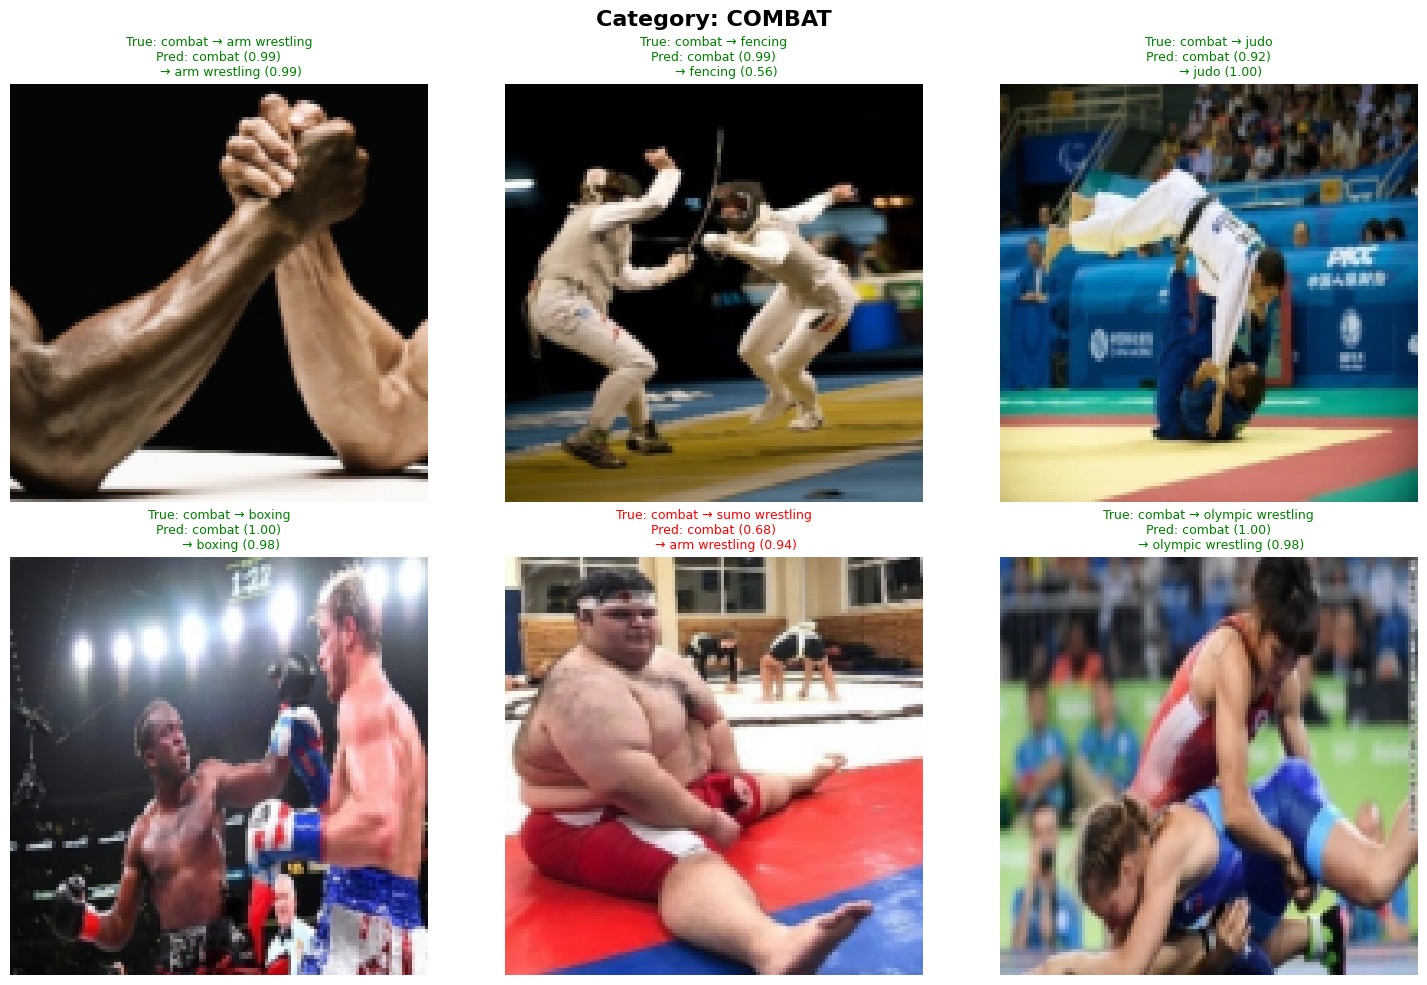

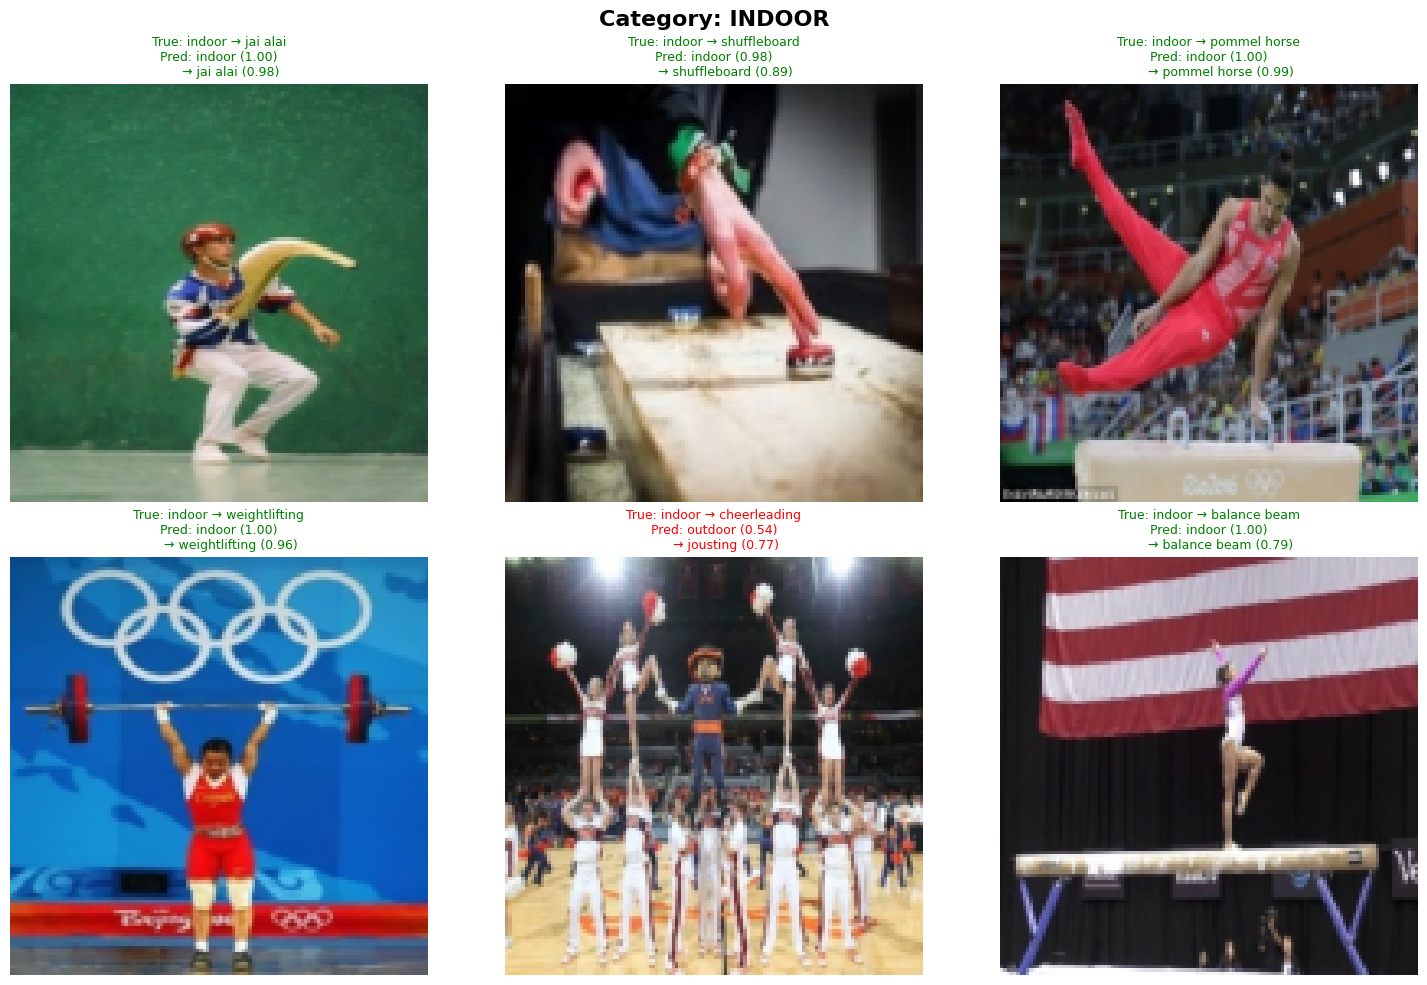

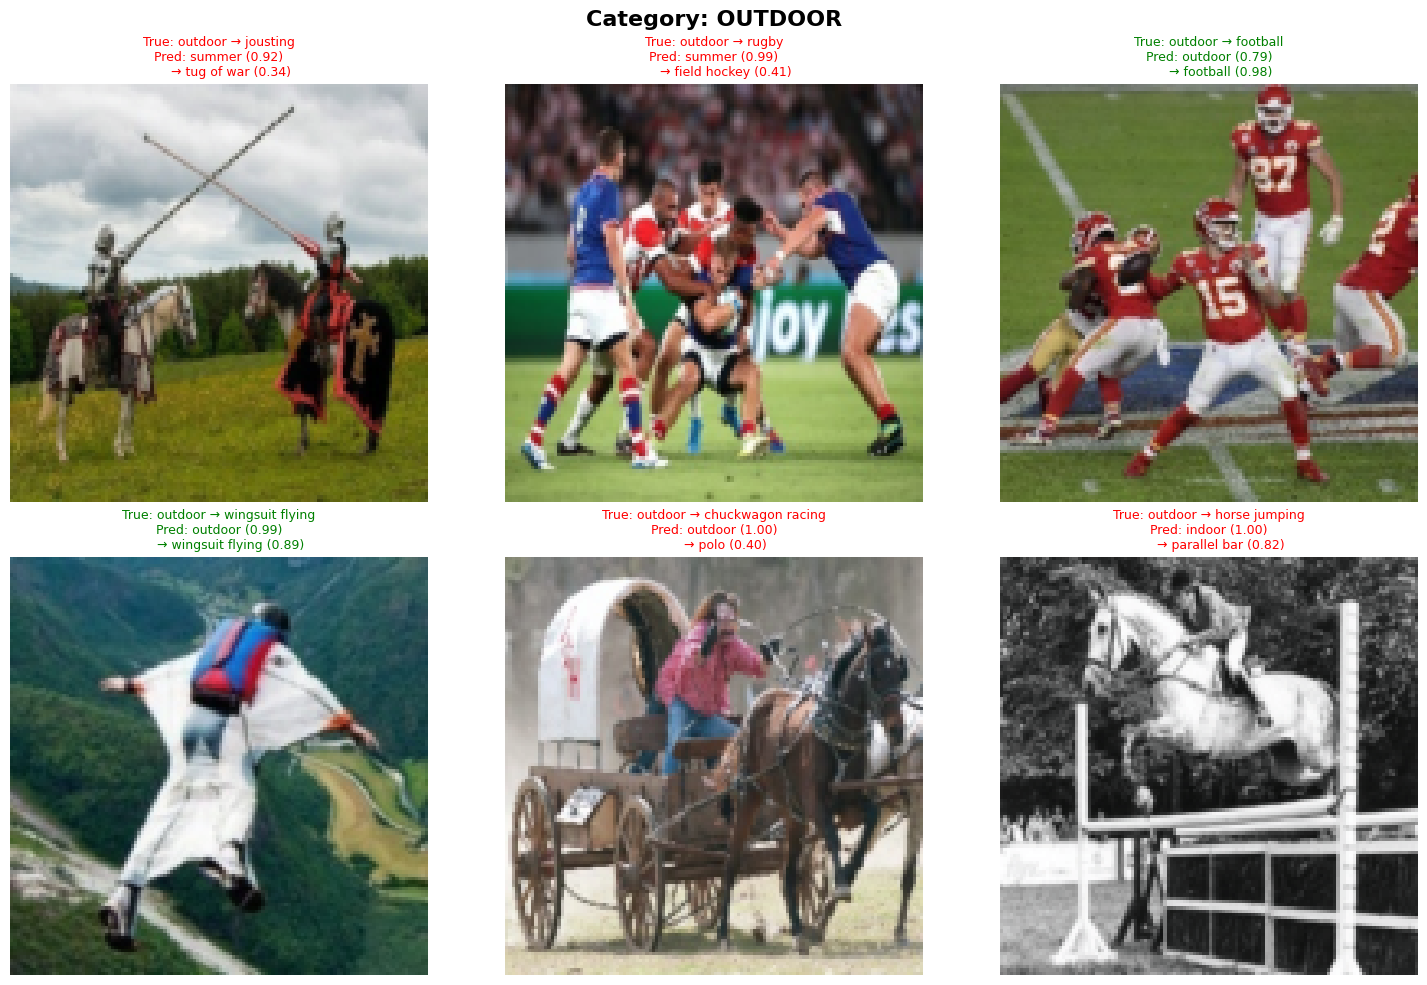

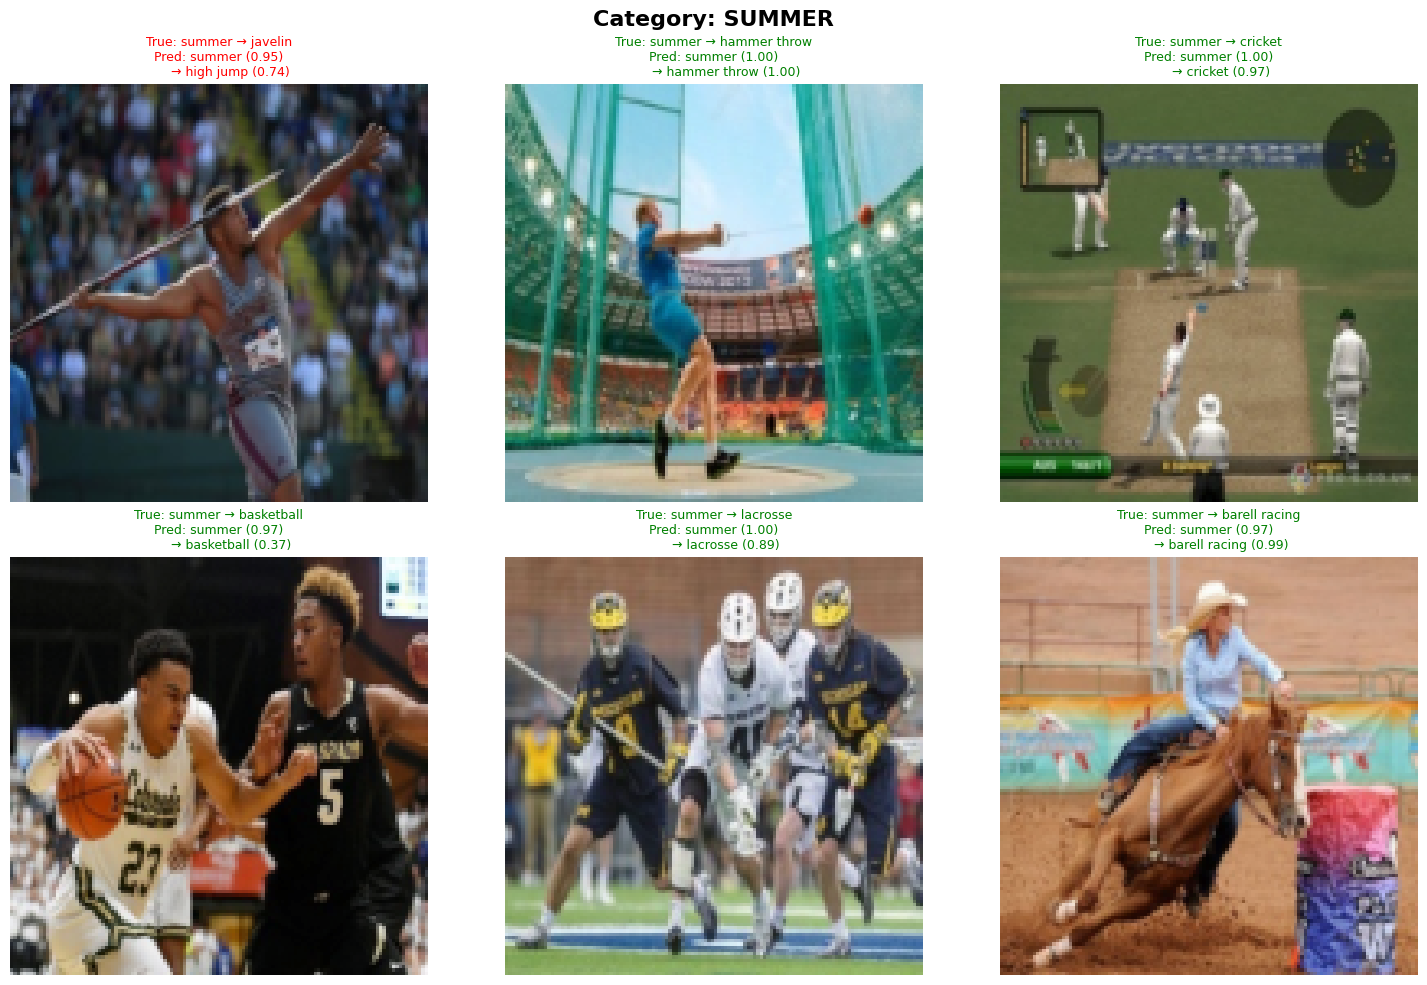

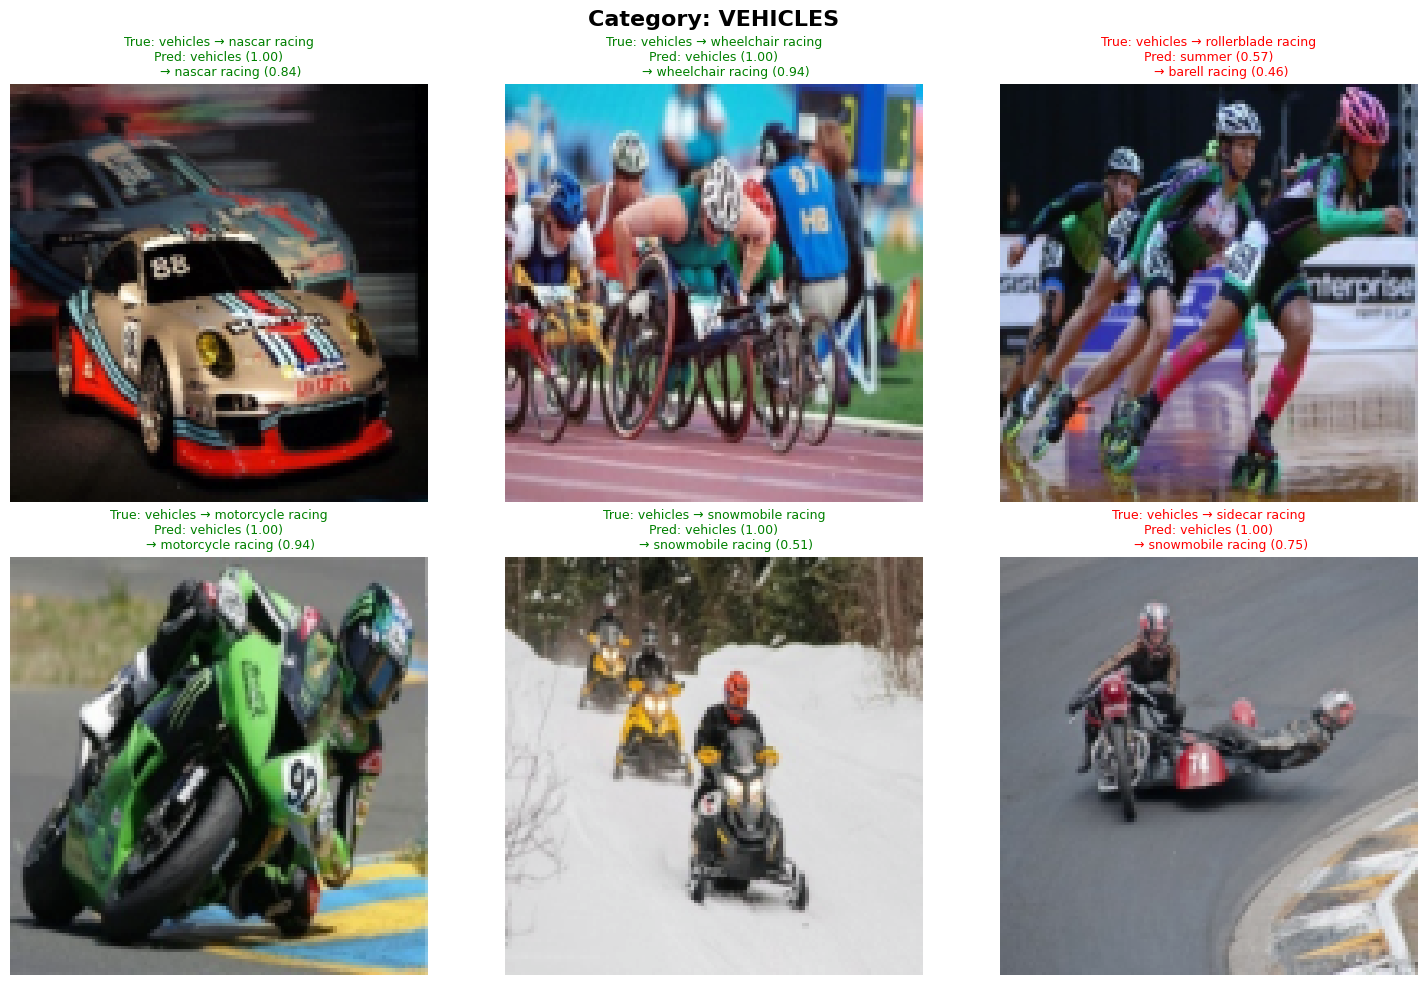

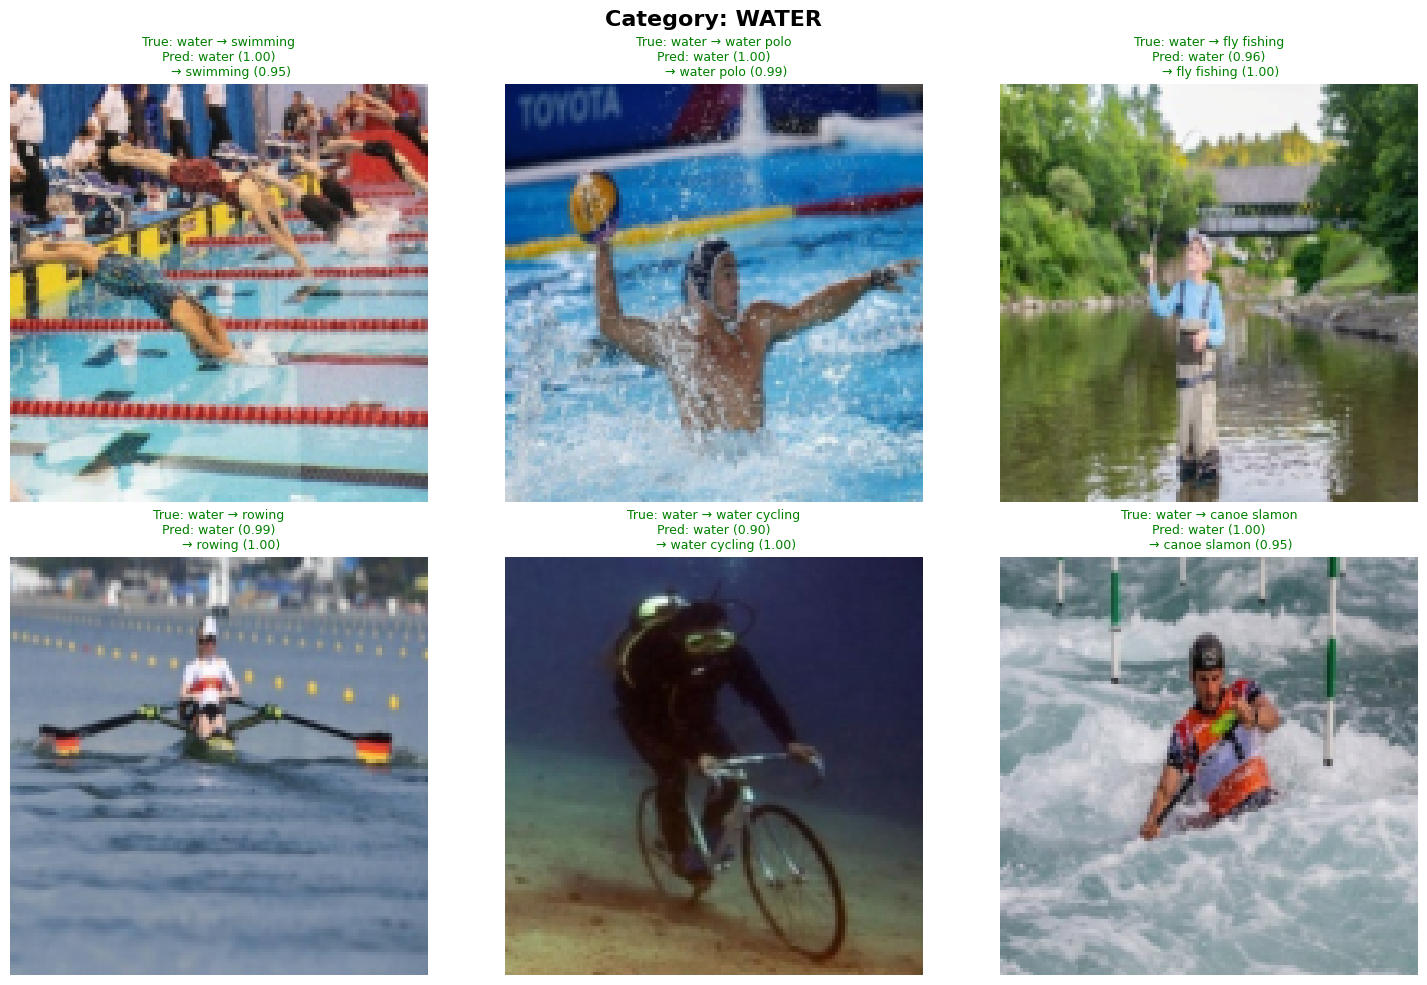

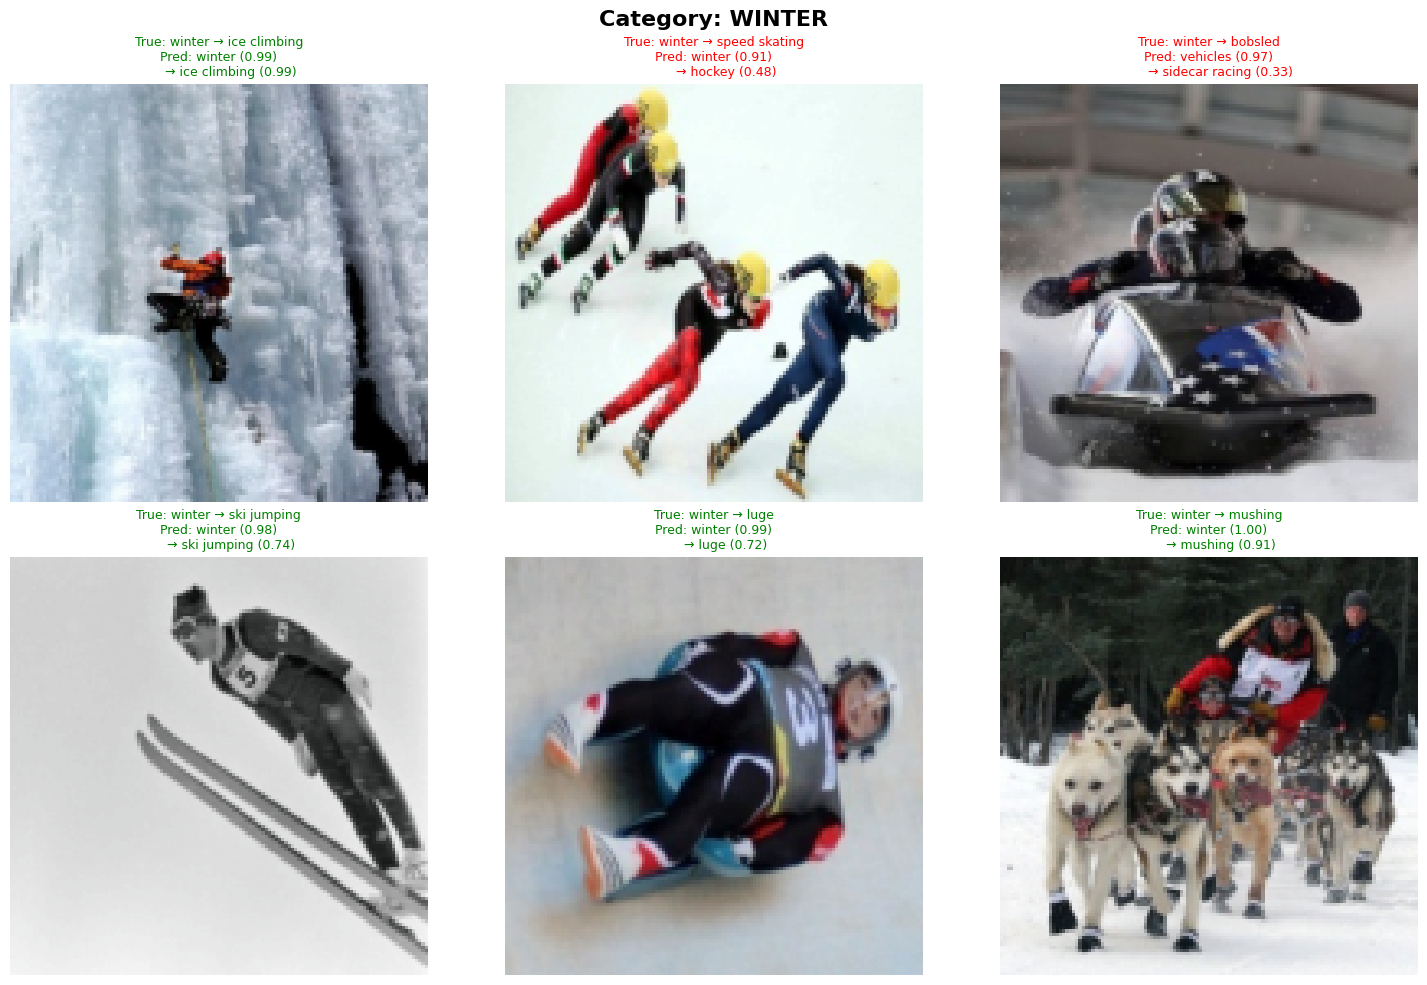

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Configuration
num_sports_per_category = 6
categories = test_base.category_classes

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Create 7 separate figures, one for each category
for category in categories:
    # Find all indices grouped by sport for this category
    sport_indices = {}  # {sport_name: [list of indices]}

    for idx in range(len(test_base)):
        _, cat_label, sport_label = test_base[idx]
        if test_base.category_classes[cat_label] == category:
            sport_name = test_base.sport_classes[sport_label]
            if sport_name not in sport_indices:
                sport_indices[sport_name] = []
            sport_indices[sport_name].append(idx)

    # Get list of unique sports in this category
    available_sports = list(sport_indices.keys())

    # Randomly select up to 6 unique sports
    num_to_sample = min(num_sports_per_category, len(available_sports))
    selected_sports = random.sample(available_sports, num_to_sample)

    # For each selected sport, pick one random image
    random_indices = []
    for sport in selected_sports:
        random_idx = random.choice(sport_indices[sport])
        random_indices.append(random_idx)

    # Create figure with 2 rows × 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    fig.suptitle(f"Category: {category.upper()}", fontsize=16, fontweight="bold")

    for i, random_idx in enumerate(random_indices):
        # Get test image
        test_image, true_cat_label, true_sport_label = test_base[random_idx]

        # Get true labels
        true_category = test_base.category_classes[true_cat_label]
        true_sport = test_base.sport_classes[true_sport_label]

        # Make prediction
        prediction = hierarchical_classifier.predict_single(test_image)

        # Denormalize image
        img_display = test_image.permute(1, 2, 0).numpy()
        img_display = img_display * std + mean
        img_display = np.clip(img_display, 0, 1)

        # Display
        axes[i].imshow(img_display)
        axes[i].axis("off")

        # Color code: green if correct, red if wrong
        cat_correct = prediction["category"] == true_category
        sport_correct = prediction["sport"] == true_sport

        title_color = "green" if (cat_correct and sport_correct) else "red"

        axes[i].set_title(
            f"True: {true_category} → {true_sport}\n"
            f"Pred: {prediction['category']} ({prediction['category_confidence']:.2f})\n"
            f"      → {prediction['sport']} ({prediction['sport_confidence']:.2f})",
            fontsize=9,
            color=title_color,
        )

    # Hide empty subplots if category has fewer than 6 unique sports
    for i in range(num_to_sample, 6):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


In [46]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)


def get_hier_preds_labels(hierarchical_classifier, test_base, device, batch_size=32):
    from torch.utils.data import DataLoader

    testloader = DataLoader(test_base, batch_size=batch_size, shuffle=False)

    all_true_cat, all_pred_cat = [], []
    all_true_sport, all_pred_sport = [], []

    for images, cat_labels, sport_labels in testloader:
        # true labels (indices)
        all_true_cat.append(cat_labels.clone())
        all_true_sport.append(sport_labels.clone())

        # predictions (names → indices)
        preds = hierarchical_classifier.predict(images)

        for p in preds:
            # category index
            cat_idx = test_base.category_classes.index(p["category"])
            all_pred_cat.append(cat_idx)

            # sport index
            sport_idx = test_base.sport_classes.index(p["sport"])
            all_pred_sport.append(sport_idx)

    true_cat = torch.cat(all_true_cat).numpy()
    true_sport = torch.cat(all_true_sport).numpy()
    pred_cat = torch.tensor(all_pred_cat).numpy()
    pred_sport = torch.tensor(all_pred_sport).numpy()

    return true_cat, pred_cat, true_sport, pred_sport


true_cat, pred_cat, true_sport, pred_sport = get_hier_preds_labels(
    hierarchical_classifier, test_base, config.DEVICE, batch_size=32
)


def print_metrics(name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    prec_weight = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec_weight = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{name} metrics:")
    print("  Accuracy:           ", acc)
    print("  Macro Precision:    ", prec_macro)
    print("  Macro Recall:       ", rec_macro)
    print("  Macro F1:           ", f1_macro)
    print("  Weighted Precision: ", prec_weight)
    print("  Weighted Recall:    ", rec_weight)
    print("  Weighted F1:        ", f1_weight)

    print("\nPer-class report:")
    print(
        classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    )


# Categories (7 classes)
print_metrics("Category level", true_cat, pred_cat, test_base.category_classes)

# Sports (≈100 classes)
print_metrics("Sport level", true_sport, pred_sport, test_base.sport_classes)



Category level metrics:
  Accuracy:            0.844
  Macro Precision:     0.8582831781166654
  Macro Recall:        0.8616893424036282
  Macro F1:            0.8595411831732356
  Weighted Precision:  0.845813070612747
  Weighted Recall:     0.844
  Weighted F1:         0.8445113060359676

Per-class report:
              precision    recall  f1-score   support

      combat       0.81      0.87      0.84        30
      indoor       0.85      0.82      0.84        80
     outdoor       0.82      0.80      0.81       130
      summer       0.76      0.81      0.79       100
    vehicles       0.87      0.91      0.89        45
       water       0.95      0.93      0.94        45
      winter       0.94      0.89      0.91        70

    accuracy                           0.84       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.85      0.84      0.84       500


Sport level metrics:
  Accuracy:            0.682
  Macro Precision:     0.68890873015873
 

In [ ]:
import numpy as np

combined_correct = (true_cat == pred_cat) & (true_sport == pred_sport)
y_true_combined = np.ones_like(combined_correct, dtype=int)
y_pred_combined = combined_correct.astype(int)


acc_combined = accuracy_score(y_true_combined, y_pred_combined)
prec_combined = precision_score(y_true_combined, y_pred_combined, zero_division=0)
rec_combined = recall_score(y_true_combined, y_pred_combined, zero_division=0)
f1_combined = f1_score(y_true_combined, y_pred_combined, zero_division=0)

print("Combined (category+sport) metrics:")
print("  Accuracy: ", acc_combined)
print("  Precision:", prec_combined)
print("  Recall:   ", rec_combined)
print("  F1-score: ", f1_combined)


Combined (category+sport) metrics:
  Accuracy:  0.682
  Precision: 1.0
  Recall:    0.682
  F1-score:  0.8109393579072532


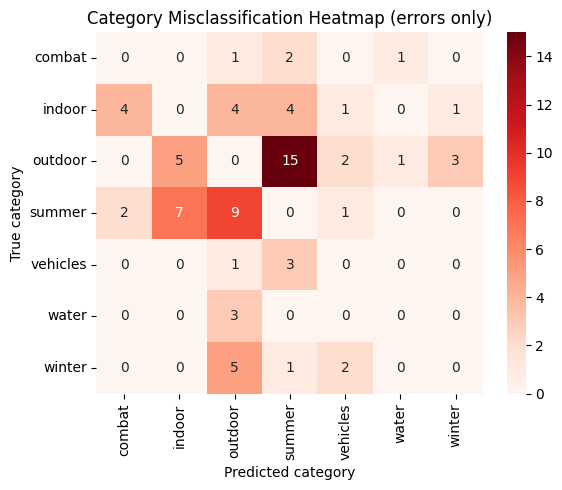

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

categories = test_base.category_classes  # e.g. ['combat','indoor',...]
num_cat = len(categories)

# Initialize confusion matrix only for errors
cat_error_matrix = np.zeros((num_cat, num_cat), dtype=int)

for t, p in zip(true_cat, pred_cat):
    if t != p:  # only count incorrect predictions
        cat_error_matrix[t, p] += 1

plt.figure(figsize=(6, 5))
sns.heatmap(
    cat_error_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=categories,
    yticklabels=categories,
)
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.title("Category Misclassification Heatmap (errors only)")
plt.tight_layout()
plt.show()


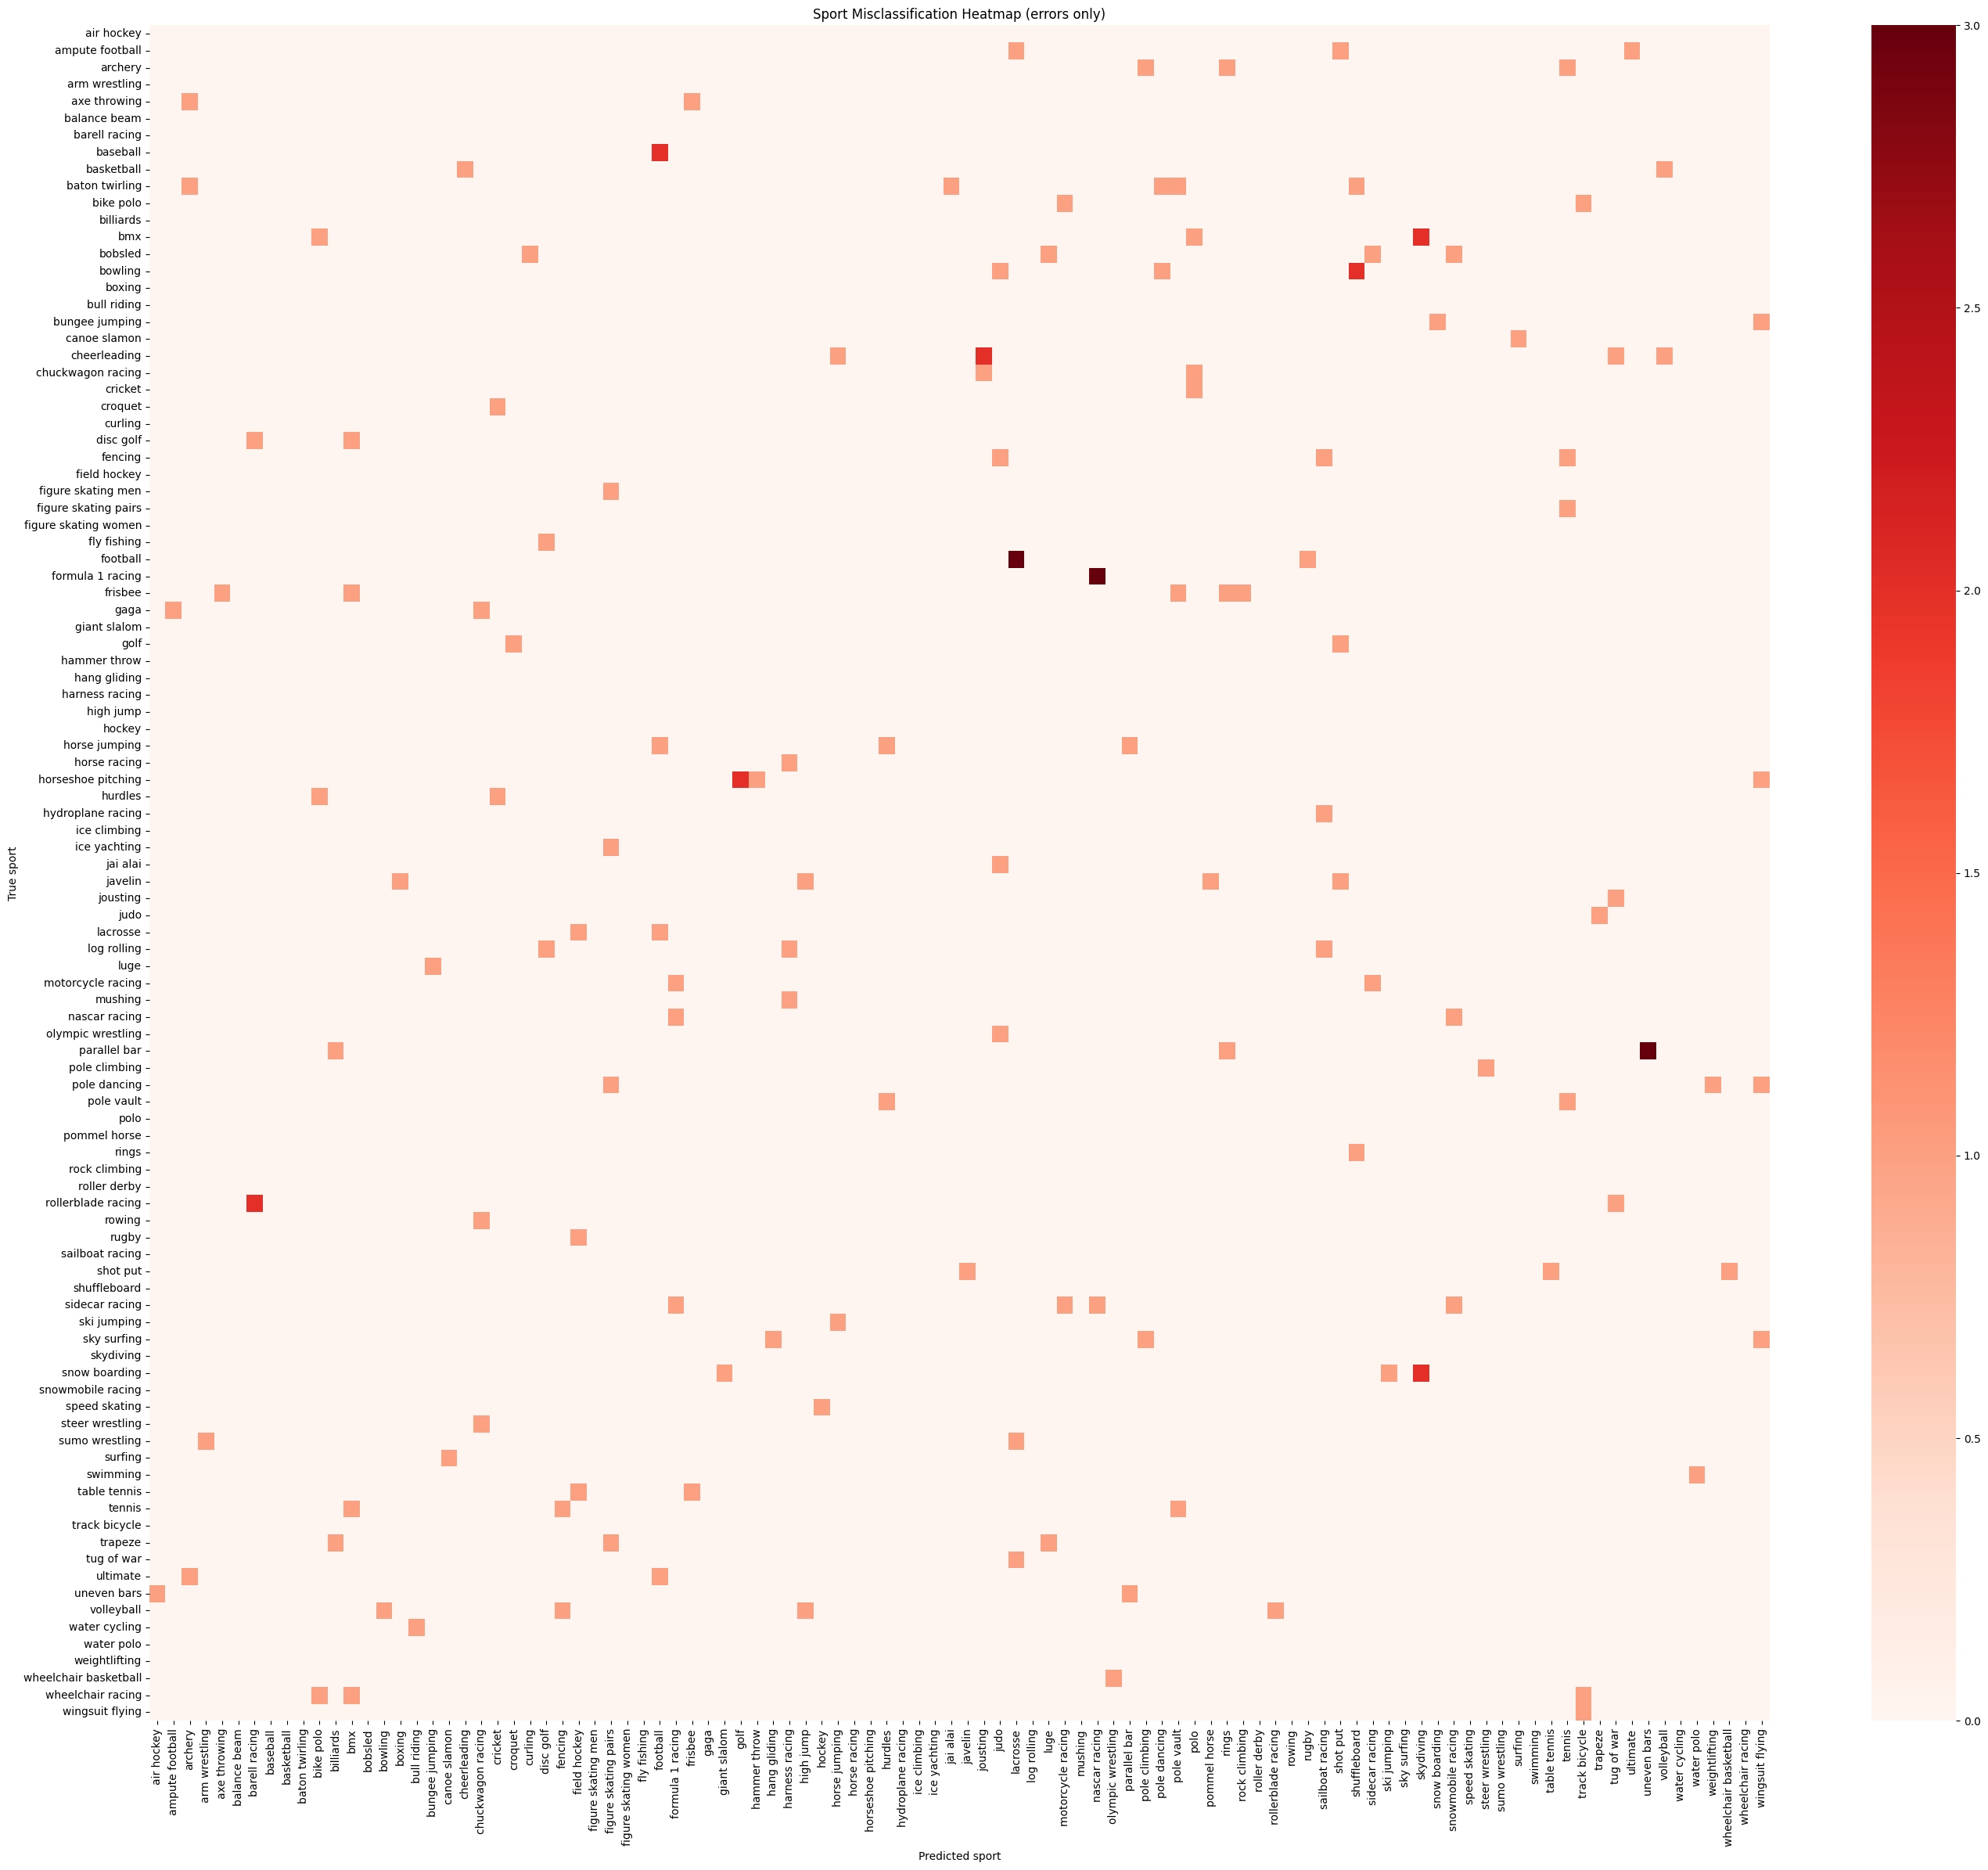

In [50]:
sports = test_base.sport_classes
num_sports = len(sports)

sport_error_matrix = np.zeros((num_sports, num_sports), dtype=int)

for t, p in zip(true_sport, pred_sport):
    if t != p:
        sport_error_matrix[t, p] += 1

plt.figure(figsize=(28, 24))
sns.heatmap(
    sport_error_matrix,
    cmap="Reds",
    xticklabels=sports,
    yticklabels=sports,
)
plt.xlabel("Predicted sport")
plt.ylabel("True sport")
plt.title("Sport Misclassification Heatmap (errors only)")
plt.tight_layout()
plt.show()


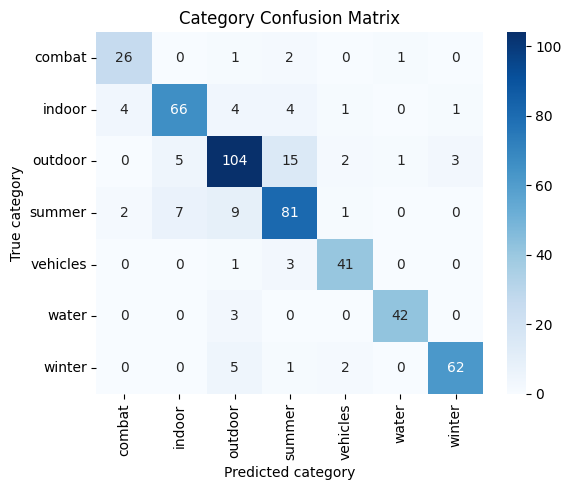

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Categories
cm_cat = confusion_matrix(true_cat, pred_cat, labels=range(len(categories)))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories,
)
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.title("Category Confusion Matrix")
plt.tight_layout()
plt.show()


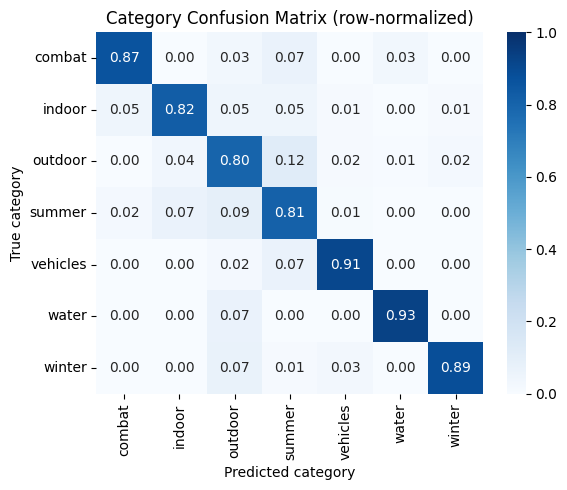

In [ ]:
cm_cat_norm = cm_cat.astype(float) / cm_cat.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cat_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories,
    vmin=0,
    vmax=1,
)
plt.xlabel("Predicted category")
plt.ylabel("True category")
plt.title("Category Confusion Matrix (row-normalized)")
plt.tight_layout()
plt.show()


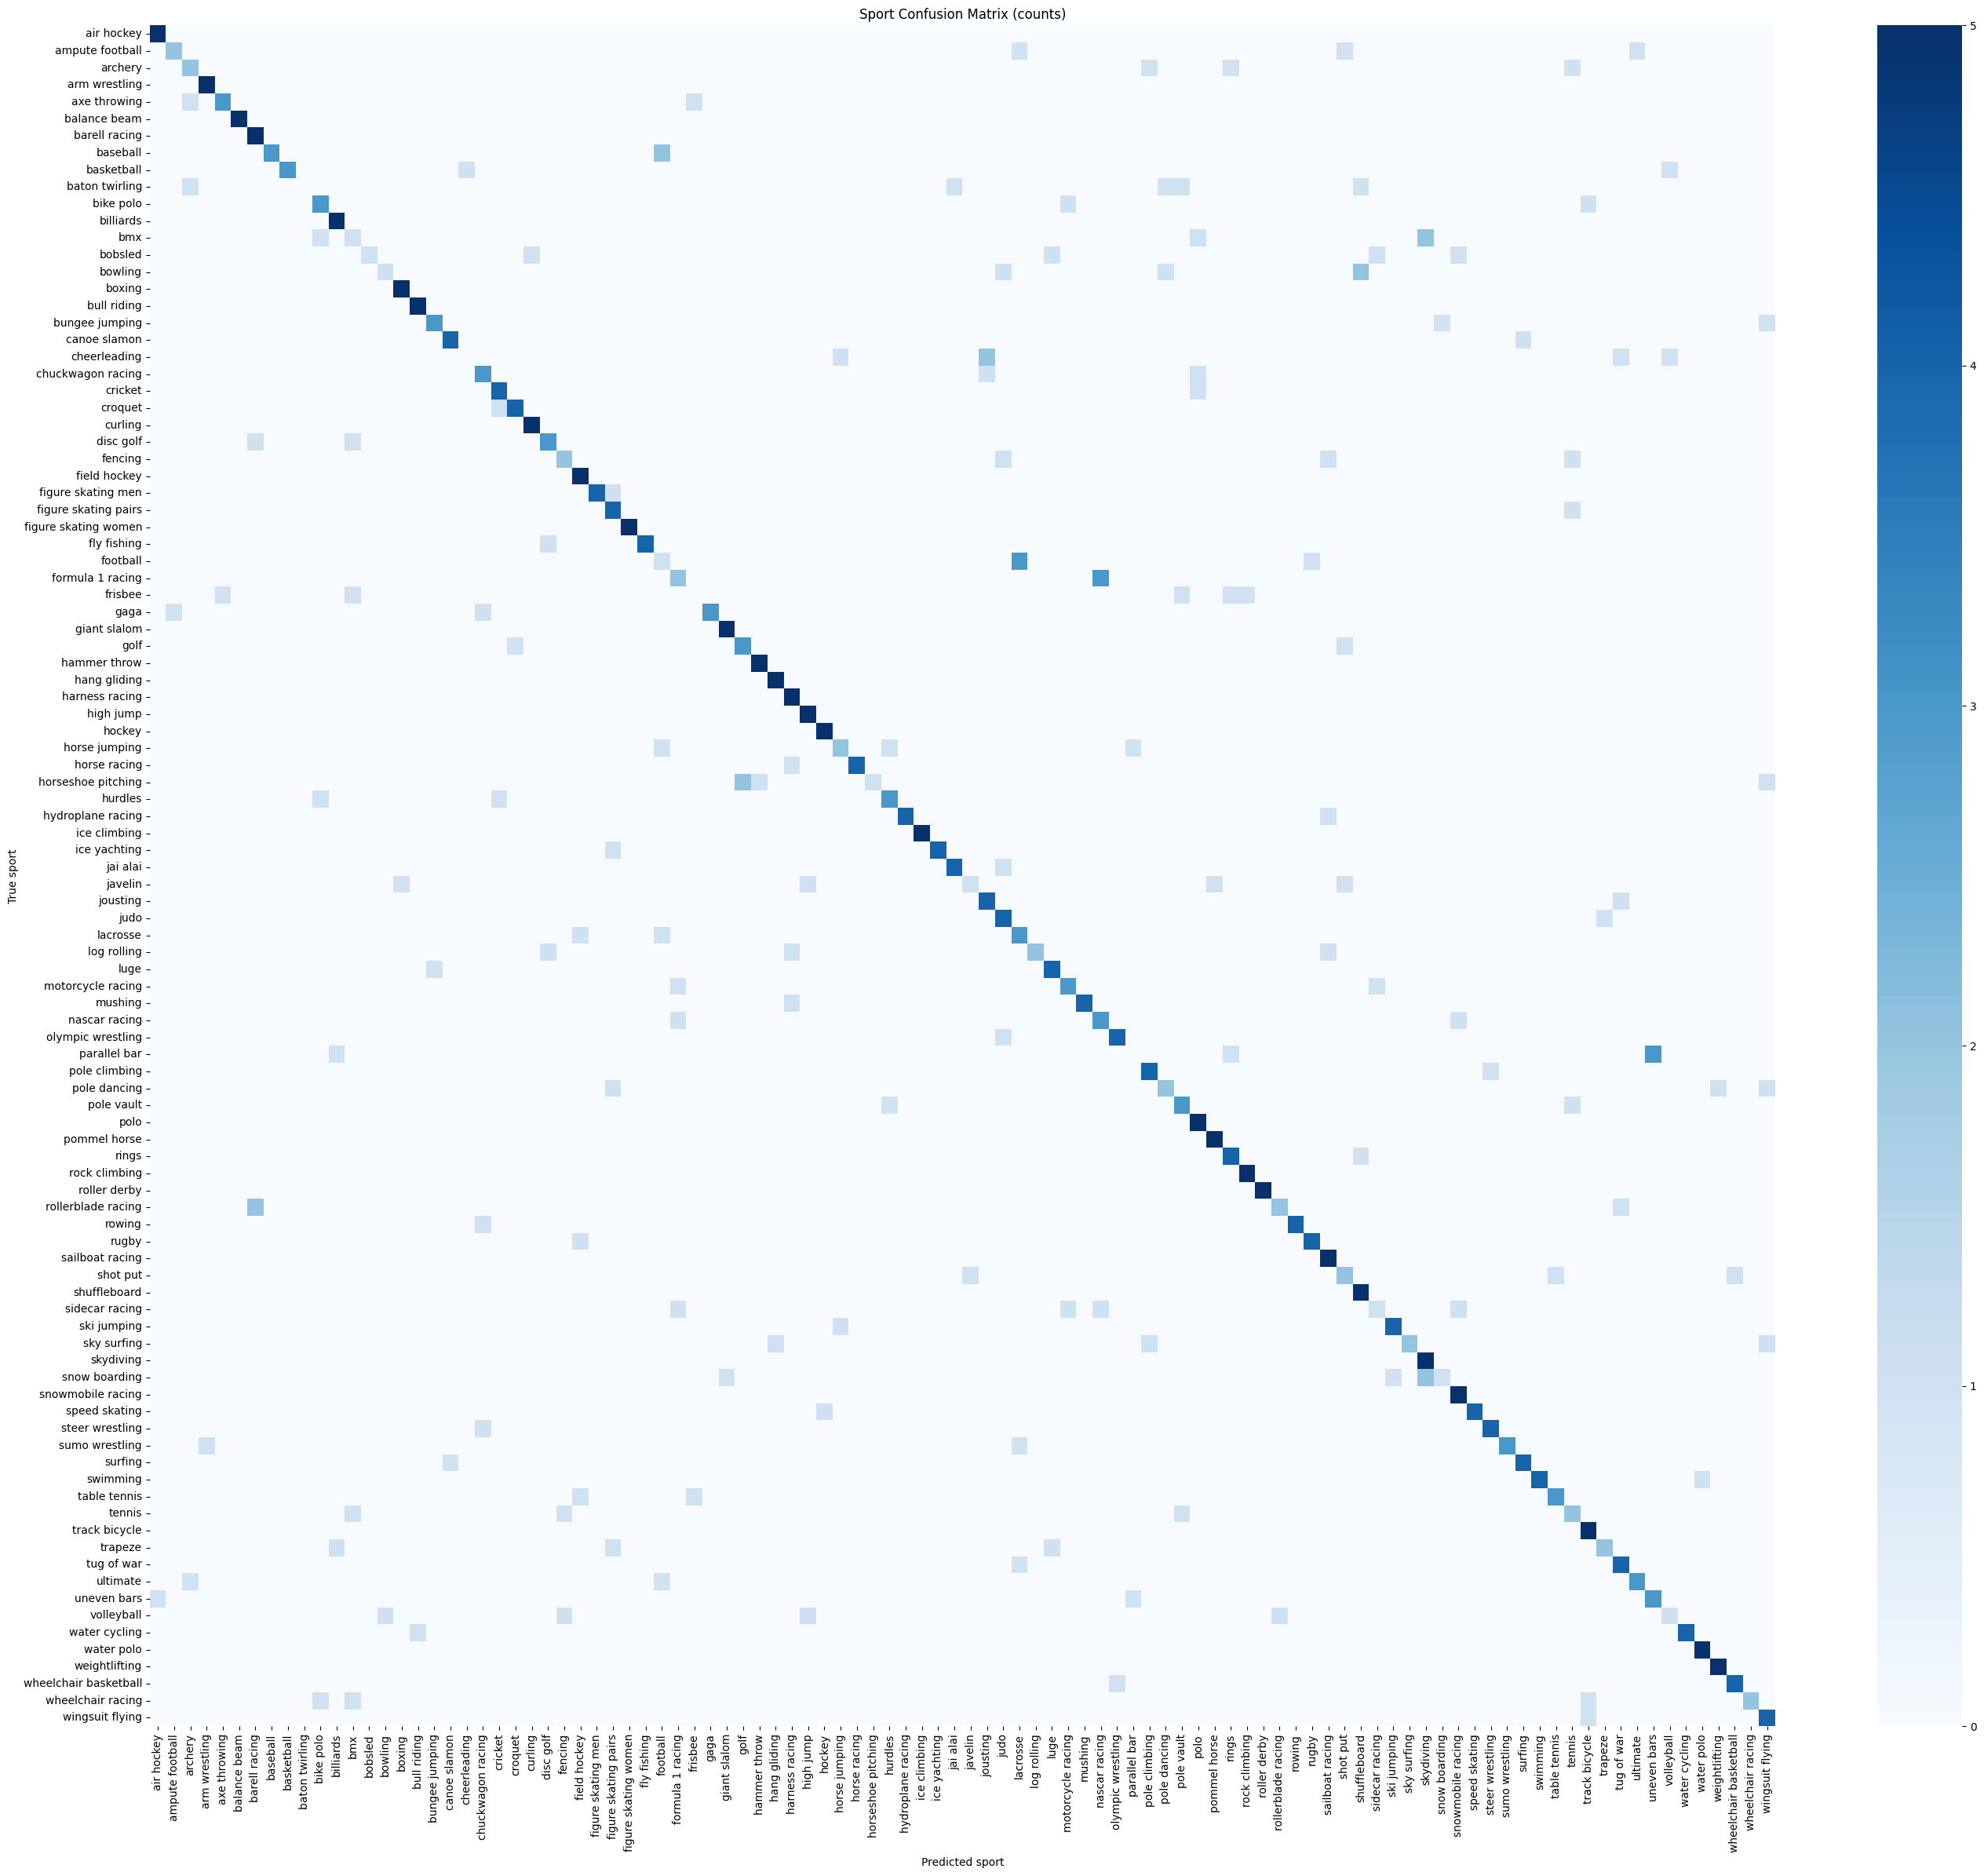

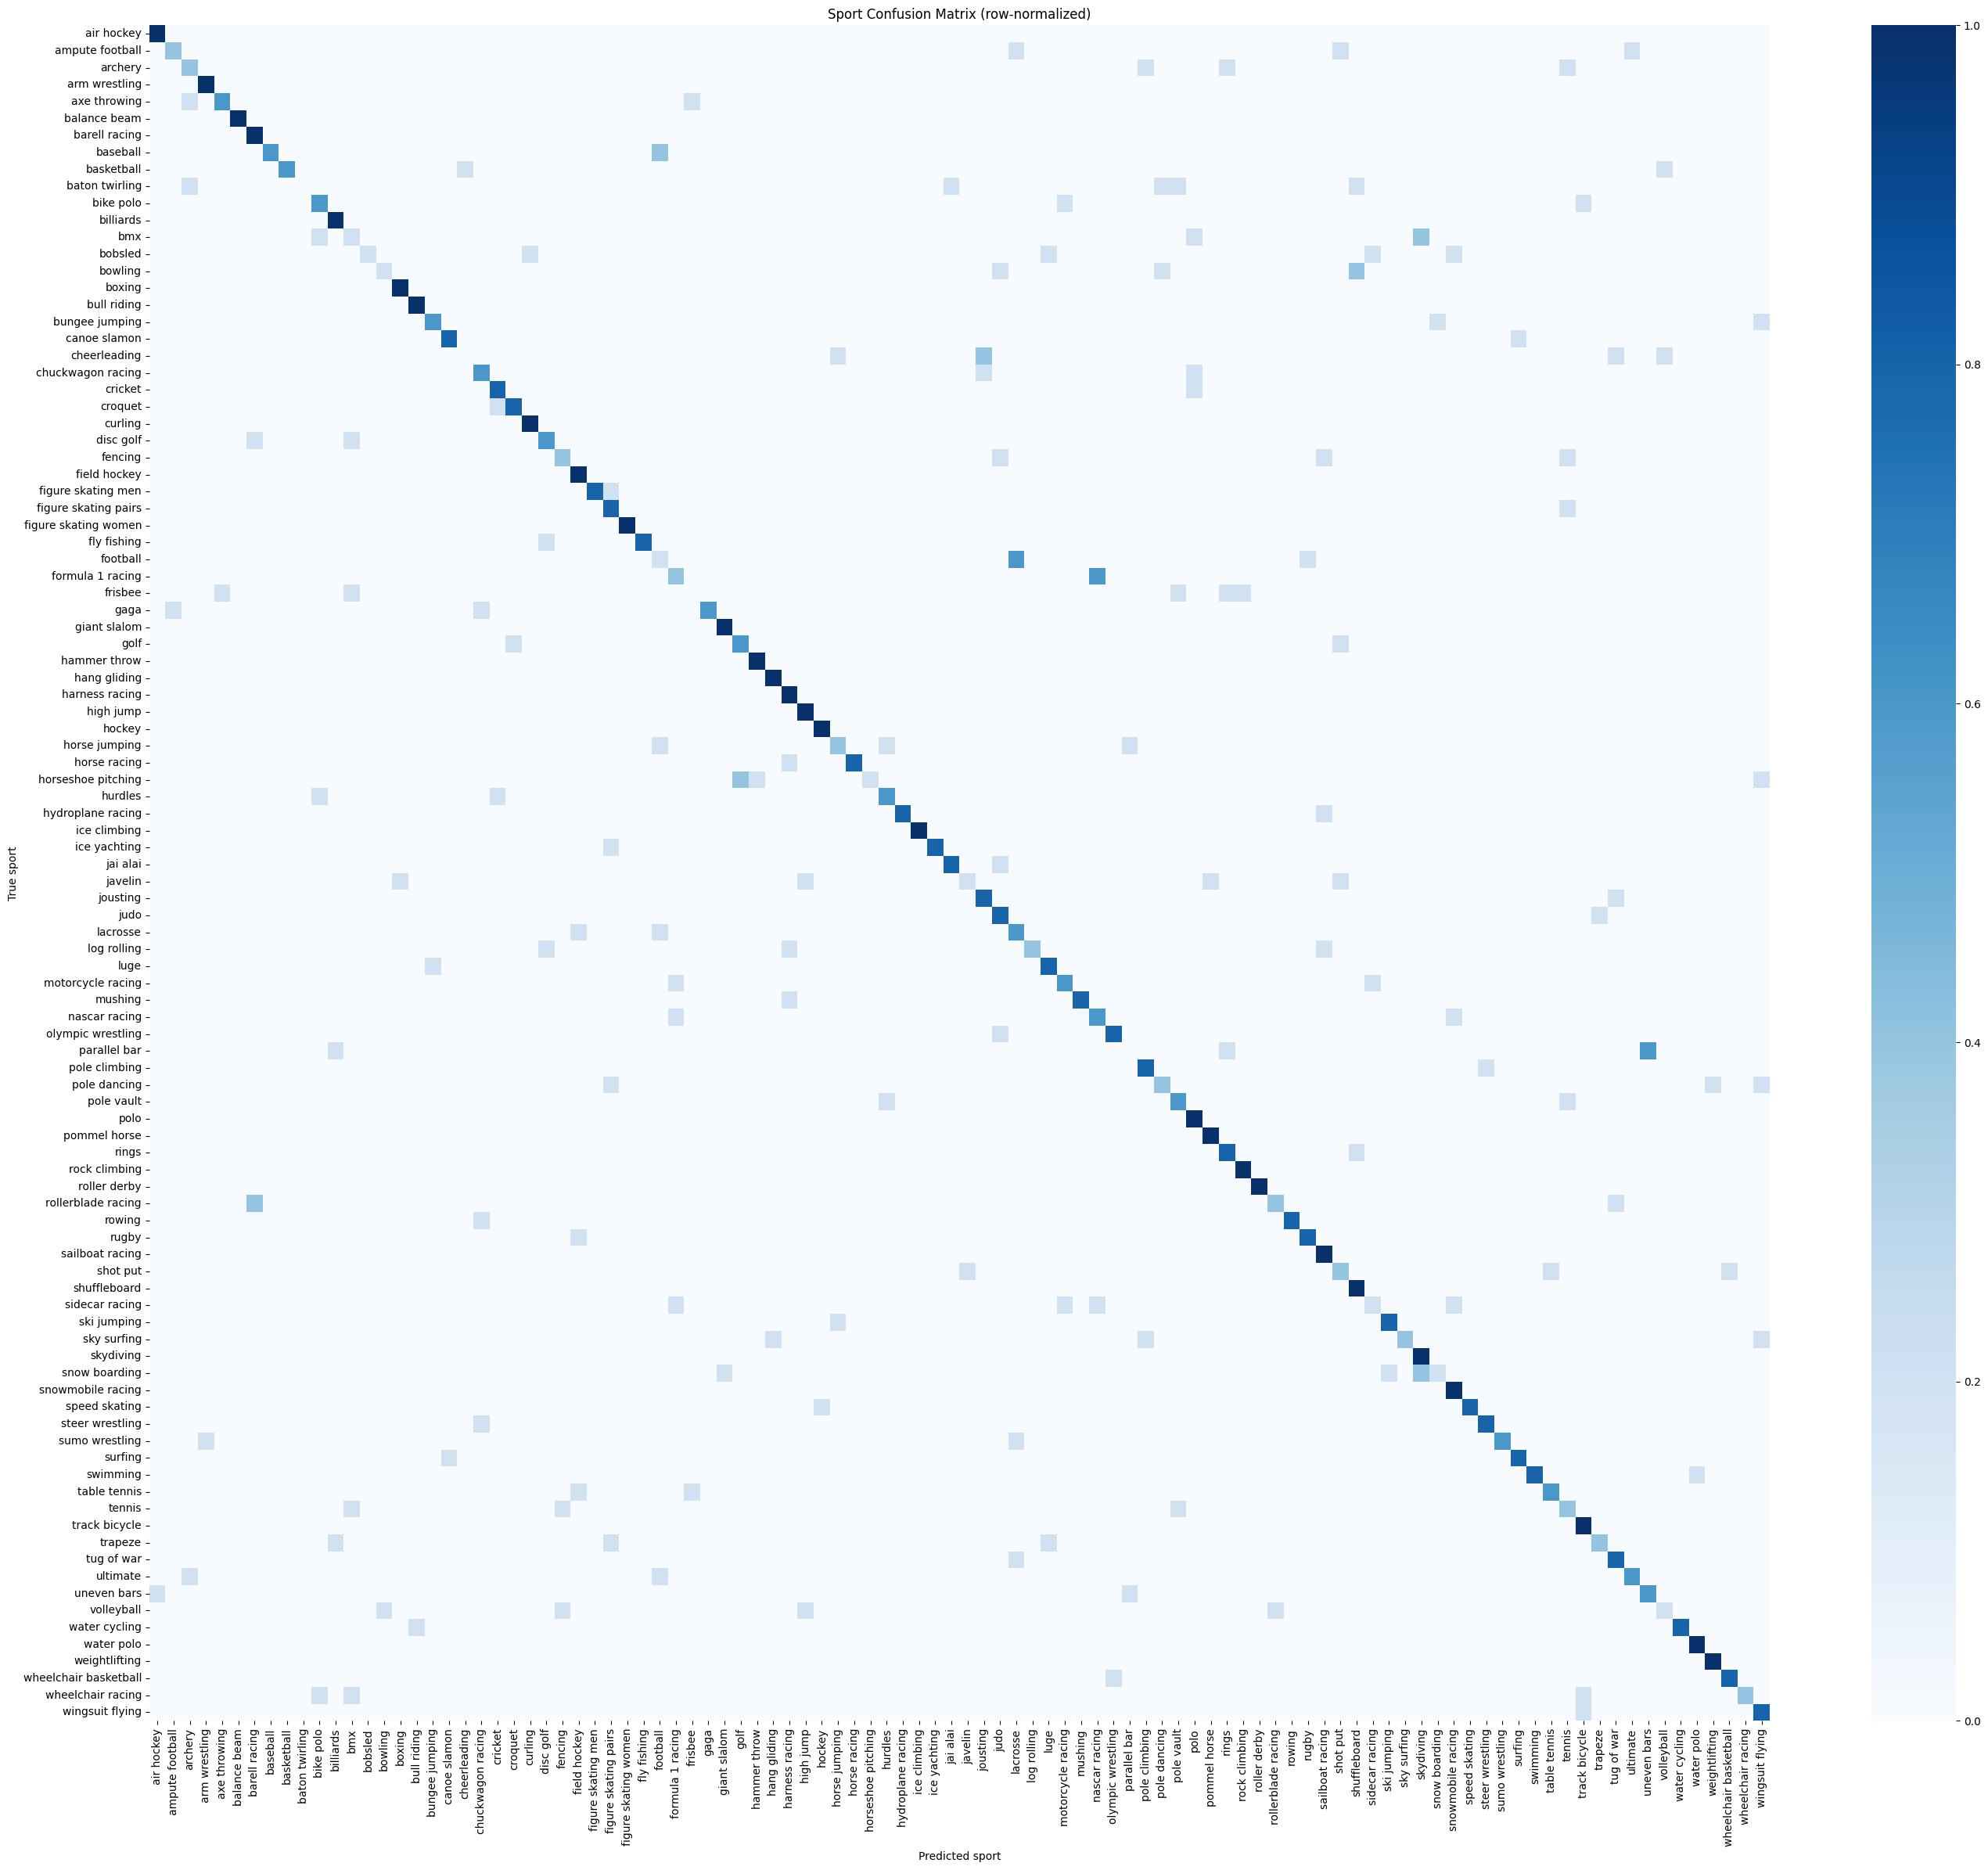

In [55]:
# Sports
cm_sport = confusion_matrix(true_sport, pred_sport, labels=range(len(sports)))

plt.figure(figsize=(28, 24))
sns.heatmap(
    cm_sport,
    cmap="Blues",
    xticklabels=sports,
    yticklabels=sports,
)
plt.xlabel("Predicted sport")
plt.ylabel("True sport")
plt.title("Sport Confusion Matrix (counts)")
plt.tight_layout()
plt.show()


cm_sport_norm = cm_sport.astype(float) / cm_sport.sum(axis=1, keepdims=True)

plt.figure(figsize=(28, 24))
sns.heatmap(
    cm_sport_norm,
    cmap="Blues",
    xticklabels=sports,
    yticklabels=sports,
    vmin=0,
    vmax=1,
)
plt.xlabel("Predicted sport")
plt.ylabel("True sport")
plt.title("Sport Confusion Matrix (row-normalized)")
plt.tight_layout()
plt.show()
